<div style="display: flex; background-color: white" >
<h1 style="margin: auto; padding: 30px; color: grey">ACP, CLUSTERING ET VISUALISATIONS</h1>
</div>

<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 1 : IMPORT LIBRAIRIES ET FICHIERS</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">1.1 Import librairies</h3>
</div>

In [1]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
#from matplotlib.collections import LineCollection

import seaborn as sns

#from sklearn import datasets
#from sklearn.cluster import AgglomerativeClustering
#from sklearn import preprocessing
#from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">1.2 Chargement du dataframe</h3>
</div>

In [2]:
df_brut = pd.read_csv("data-output/df_column_added.csv", index_col="Pays")

# Afficher les 2 premières et 2 dernières lignes
display(df_brut.head(2))
display(df_brut.tail(2))

,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
Pays,,,,,,,,,,,,,,,,
Afghanistan,2022,0.87,7.0,29.0,Asie,4,AFG,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.000
Afrique du Sud,2022,35.47,304.0,1958.0,Afrique,710,ZAF,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.026


,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
Pays,,,,,,,,,,,,,,,,
États-Unis d’Amérique,2022,53.75,191.0,22272.0,Amériques,840,USA,0.49,3.9,76657.248884,0.008701,334017321.0,22.7,0.0085,0.6995,0.3183
Îles Salomon,2022,8.72,7.0,0.0,Océanie,90,SLB,7.08,2.6,1877.781045,0.413906,781066.0,-17.6,1.0000,0.2959,0.1365


<div style="border: 1px solid white;background : rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white ">ETAPE 2 : DATA PREPARATION</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">2.1 Data selection</h3>
</div>

In [3]:
# On enlève Chine, Brésil, Etats-Unis, Inde de l'analyse (pays autosuffisants ou concurrents directs)
df = df_brut.drop(["Chine", "États-Unis d’Amérique", "Inde", "Brésil"])

In [4]:
# On sélectionne les colonnes souhaitées uniquement
# Rappelons d'abord le nom de toutes les colonnes dans notre dataframe
df.columns

Index(['Year', 'Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)', 'Region',
       'M49 Code', 'ISO-alpha3 Code', 'Part_bio_pct', 'Logistique',
       'PIB_hab_dollar_us_courants', 'Stabilite_pol', 'Population',
       'PIB_hab_evol_18_22_pct', 'Deficit_avicole', 'Score_attractivite',
       'Potentiel_bio'],
      dtype='str')

In [5]:
# Enregistrons les colonnes souhaitées dans une variable
cols = ['Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)',
       'Part_bio_pct', 'Logistique',
       'PIB_hab_dollar_us_courants', 'Stabilite_pol', 'Population',
       'PIB_hab_evol_18_22_pct', 'Deficit_avicole',
       'Score_attractivite', 'Potentiel_bio']

In [6]:
# Sélection des colonnes et affichage du nouveau dataframe
df = df[cols]
df.head()

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
Pays,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 96 entries, Afghanistan to Îles Salomon
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Disponibilité alimentaire (kg/personne/an)  96 non-null     float64
 1   Importations - quantité (1000 t)            96 non-null     float64
 2   Production (1000 t)                         96 non-null     float64
 3   Part_bio_pct                                96 non-null     float64
 4   Logistique                                  96 non-null     float64
 5   PIB_hab_dollar_us_courants                  96 non-null     float64
 6   Stabilite_pol                               96 non-null     float64
 7   Population                                  96 non-null     float64
 8   PIB_hab_evol_18_22_pct                      96 non-null     float64
 9   Deficit_avicole                             96 non-null     float64
 10  Score_attrac

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">2.2 Data split</h3>
</div>

In [8]:
# Séparons nos données.
# Soit X la matrice des données :
X = df.values
X[:5]

array([[ 8.70000000e-01,  7.00000000e+00,  2.90000000e+01,
         0.00000000e+00,  1.70000000e+00,  3.57261153e+02,
        -2.54495597e+00,  4.05788420e+07, -2.73000000e+01,
         1.94400000e-01,  0.00000000e+00,  0.00000000e+00],
       [ 3.54700000e+01,  3.04000000e+02,  1.95800000e+03,
         5.00000000e-02,  3.60000000e+00,  6.53424868e+03,
        -6.81386352e-01,  6.23784100e+07, -5.50000000e+00,
         1.34400000e-01,  3.88700000e-01,  2.60000000e-02],
       [ 2.26800000e+01,  4.70000000e+01,  1.80000000e+01,
         6.00000000e-02,  2.70000000e+00,  7.75696189e+03,
         1.06261313e-01,  2.45163600e+06,  3.15000000e+01,
         7.23100000e-01,  3.32100000e-01,  3.11000000e-02],
       [ 9.71000000e+00,  0.00000000e+00,  4.43000000e+02,
         0.00000000e+00,  2.10000000e+00,  4.96030334e+03,
        -6.50652349e-01,  4.54773890e+07,  8.40000000e+00,
         0.00000000e+00,  1.91700000e-01,  1.87000000e-02],
       [ 1.66300000e+01,  7.89000000e+02,  1.5080000

In [9]:
# On vérifie que X est constituée uniquement de valeurs numériques
type (X)

numpy.ndarray

In [10]:
# On vérifie la dimension de X
X.shape

(96, 12)

In [11]:
# Enregistrons les noms des pays dans une variable "names"
names = df.index
names

Index(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Arabie saoudite', 'Argentine', 'Arménie', 'Australie', 'Autriche',
       'Bahamas', 'Bangladesh', 'Belgique', 'Bolivie (État plurinational de)',
       'Bosnie-Herzégovine', 'Bulgarie', 'Burkina Faso', 'Cambodge',
       'Cameroun', 'Canada', 'Chili', 'Chypre', 'Colombie', 'Costa Rica',
       'Croatie', 'Danemark', 'El Salvador', 'Espagne', 'Estonie', 'Fidji',
       'Finlande', 'France', 'Fédération de Russie', 'Ghana', 'Grèce',
       'Guatemala', 'Guinée-Bissau', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie',
       'Indonésie', 'Iran (République islamique d’)', 'Iraq', 'Irlande',
       'Islande', 'Israël', 'Italie', 'Jamaïque', 'Kazakhstan', 'Kirghizistan',
       'Koweït', 'Lettonie', 'Lituanie', 'Luxembourg', 'Macédoine du Nord',
       'Madagascar', 'Malaisie', 'Malte', 'Mexique', 'Monténégro', 'Nigéria',
       'Norvège', 'Nouvelle-Zélande', 'Oman', 'Panama',
       'Papouasie-Nouvelle-Guinée', 'P

In [12]:
# Enregistrons nos colonnes dans une variable features
features = df.columns
features

Index(['Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)',
       'Part_bio_pct', 'Logistique', 'PIB_hab_dollar_us_courants',
       'Stabilite_pol', 'Population', 'PIB_hab_evol_18_22_pct',
       'Deficit_avicole', 'Score_attractivite', 'Potentiel_bio'],
      dtype='str')

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">2.3 Scaling</h3>
</div>

In [13]:
# On commence par scaler les données. Instanciation :
scaler = StandardScaler()

In [14]:
# On fit
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
# On transforme
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-1.59666167, -0.55069641, -0.63195866, -0.69824345, -1.91354463,
        -0.86895026, -2.90882908,  0.18038004, -2.69477245, -0.3759565 ,
        -2.18457082, -0.94306196],
       [ 0.77314945,  0.82264882,  1.33006178, -0.68986663,  0.82180443,
        -0.63008658, -0.74920139,  0.63864045, -1.29237036, -0.57953349,
        -0.05895193, -0.79691888],
       [-0.10285876, -0.36573409, -0.64314696, -0.68819126, -0.47388723,
        -0.58280435,  0.16357679, -0.62111242,  1.08785338,  1.41789603,
        -0.36847091, -0.76825236],
       [-0.99119548, -0.58306481, -0.21087185, -0.69824345, -1.33768167,
        -0.69095094, -0.7135848 ,  0.28335502, -0.39817819, -1.03554593,
        -1.13625298, -0.83795136],
       [-0.51723325,  3.06531694,  0.87235872,  0.92183493,  1.82956462,
         1.07031801,  0.7687721 ,  1.07587586, -0.72626309,  0.1299323 ,
         1.21849745,  1.19962034]])

In [16]:
# On espère avoir une moyenne à 0 et un écart type à 1
idx = ["mean", "std"]
pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8,9,10,11
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01


<div style="border: 1px solid white;background : rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white ">ETAPE 3 : ANALYSE ACP</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.1 ACP</h3>
</div>

In [17]:
# Configuration du nombre de composantes avec lesquelles nous allons travailler
n_components = 6

In [18]:
# Instanciation de notre ACP
pca = PCA(n_components=n_components)

In [19]:
# On l'entraîne sur les données scalées
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",6
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.2 Variance expliquée & scree plot</h3>
</div>

In [20]:
pca.explained_variance_ratio_

array([0.39721378, 0.18129315, 0.09668482, 0.09561828, 0.08575688,
       0.04706845])

On constate que la première composante capte 39% de la variance de nos données initiales, la 2ème 18% etc...

In [21]:
# On stocke les résultats dans une variable
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([39.72, 18.13,  9.67,  9.56,  8.58,  4.71])

Les deux premières composantes captent dont 40+18 = 58 % de la variance, les 3 premières 40+18+10 = 68% de la variance etc...(Somme cumulée)

In [22]:
# Calcul de la somme cumulée
scree_cum = scree.cumsum().round()
scree_cum

array([40., 58., 68., 77., 86., 90.])

In [23]:
# On définit ensuite une variable avec la liste de nos composantes
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6]

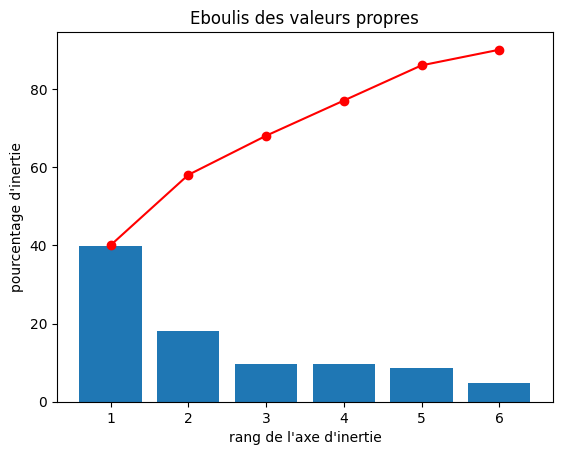

In [24]:
# Affichage graphique
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.savefig("data-output/N2-Eboulis_valeurs_propres.png", bbox_inches="tight")
plt.show(block=False)

En bleu, la variance de chaque nouvelle composante, en rouge la variance cumulée.
<br>On voit ici que près de 70% de la variance est comprise dans les 3 premières composantes.

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.3 Composantes principales</h3>
</div>

In [25]:
# Dans cette section, nous allons nous intéresser à la projection de nos données sur les composantes principales.
# Nous allons ainsi pouvoir visualiser nos données dans un espace de dimension réduite, tout en conservant une grande partie de l'information initiale.
# Nous allons également visualiser les contributions de chaque variable à ces composantes principales, afin de mieux comprendre quelles sont les variables qui expliquent le mieux la variance de nos données.

In [26]:
# Ici, nous allons nous intéresser aux composantes principales elles-mêmes, c'est-à-dire aux vecteurs qui définissent les axes de notre espace de projection.
# Ces composantes sont données par la matrice des composantes principales "pca.components_", que nous allons afficher ci-dessous.
# On va stocker cette matrice dans la variable "pcs" pour "principal components"
pcs = pca.components_
pcs

array([[ 1.65750542e-01,  9.24459228e-02, -5.55920353e-02,
         3.05542560e-01,  3.90108748e-01,  3.92651043e-01,
         3.82817972e-01, -1.73674442e-01, -1.01576045e-01,
         6.35192478e-02,  4.40143090e-01,  4.19980193e-01],
       [ 2.17492308e-01,  3.41037005e-01,  6.18069022e-01,
        -8.99344453e-02,  2.23211287e-01,  5.05513419e-02,
        -9.08516264e-02,  5.01825942e-01,  5.78624011e-02,
        -3.43564117e-01,  1.08556191e-01, -2.57394496e-02],
       [ 7.04224446e-01, -2.41071133e-01, -5.66953634e-03,
        -3.63711437e-01, -8.56289644e-02, -3.79566893e-02,
         1.69127482e-01, -3.50099327e-01, -3.94758753e-02,
        -2.73596202e-01,  1.27695123e-01, -2.46918086e-01],
       [ 1.60597983e-01,  5.22508280e-01, -4.90163022e-02,
        -3.69708931e-01,  4.19386923e-02,  1.08898527e-01,
        -3.41791010e-02, -8.49547218e-02,  3.03461257e-01,
         6.44478131e-01,  7.57238569e-02, -1.64097336e-01],
       [ 2.96265278e-04, -4.18638725e-01, -2.0045552

In [27]:
# Ici, nous allons convertir notre matrice de composantes principales en un dataframe pandas, afin de faciliter la lecture et l'interprétation des résultats.
pcs = pd.DataFrame(pcs)
pcs = pcs.loc[[0,1,2,3], :]
pcs

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.165751,0.092446,-0.055592,0.305543,0.390109,0.392651,0.382818,-0.173674,-0.101576,0.063519,0.440143,0.419980
1,0.217492,0.341037,0.618069,-0.089934,0.223211,0.050551,-0.090852,0.501826,0.057862,-0.343564,0.108556,-0.025739
2,0.704224,-0.241071,-0.005670,-0.363711,-0.085629,-0.037957,0.169127,-0.350099,-0.039476,-0.273596,0.127695,-0.246918
3,0.160598,0.522508,-0.049016,-0.369709,0.041939,0.108899,-0.034179,-0.084955,0.303461,0.644478,0.075724,-0.164097


In [28]:
# Ici, nous mettons en forme notre dataframe, en lui donnant des noms de colonnes et d'index plus explicites.
pcs.columns = features
pcs.index = [f"F{i}" for i in range (1,5)]
pcs = pcs.round(2) # résultat arrondi pour simplifier l'analyse
pcs

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
F1,0.17,0.09,-0.06,0.31,0.39,0.39,0.38,-0.17,-0.10,0.06,0.44,0.42
F2,0.22,0.34,0.62,-0.09,0.22,0.05,-0.09,0.50,0.06,-0.34,0.11,-0.03
F3,0.70,-0.24,-0.01,-0.36,-0.09,-0.04,0.17,-0.35,-0.04,-0.27,0.13,-0.25
F4,0.16,0.52,-0.05,-0.37,0.04,0.11,-0.03,-0.08,0.30,0.64,0.08,-0.16


In [29]:
# Ainsi F1 = 0.17*Dispo alim + 0.09*Importations -0.06*Production etc...(Combinaison linéaire de nos variables initiales)

In [30]:
# Ici, nous transposons notre dataframe, afin d'avoir les composantes principales en colonnes et les variables en lignes.
# Cela nous facilite la lecture
pcs.T

,F1,F2,F3,F4
Disponibilité alimentaire (kg/personne/an),0.17,0.22,0.70,0.16
Importations - quantité (1000 t),0.09,0.34,-0.24,0.52
Production (1000 t),-0.06,0.62,-0.01,-0.05
Part_bio_pct,0.31,-0.09,-0.36,-0.37
Logistique,0.39,0.22,-0.09,0.04
PIB_hab_dollar_us_courants,0.39,0.05,-0.04,0.11
Stabilite_pol,0.38,-0.09,0.17,-0.03
Population,-0.17,0.50,-0.35,-0.08
PIB_hab_evol_18_22_pct,-0.10,0.06,-0.04,0.30
Deficit_avicole,0.06,-0.34,-0.27,0.64


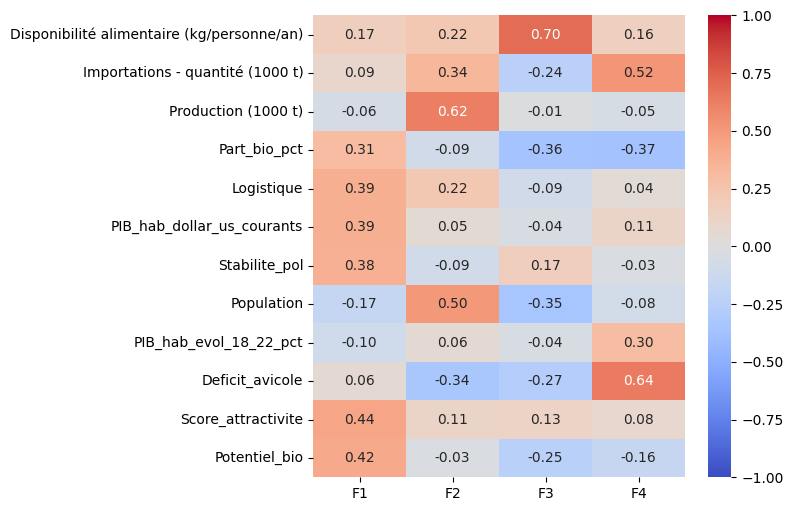

In [31]:
# Ici, nous allons afficher les composantes principales sous forme de heatmap, afin de visualiser plus facilement les contributions de chaque variable à ces composantes.
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")
plt.savefig("data-output/N2-heatmap-composantes.png", bbox_inches="tight")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.4 Cercle de corrélations</h3>
</div>

In [32]:
# Dans cette section, nous allons visualiser les composantes principales sous forme de cercle de corrélation, afin de mieux comprendre les relations entre les variables et les composantes.

In [33]:
# Création de la fonction correlation_graph qui affiche le cercle des corrélations

def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes, save et display
    plt.axis('equal')
    plt.savefig("data-output/N2-Cercle des corrélations (F{} et F{}).png".format(x+1, y+1), bbox_inches="tight")
    plt.show(block=False)

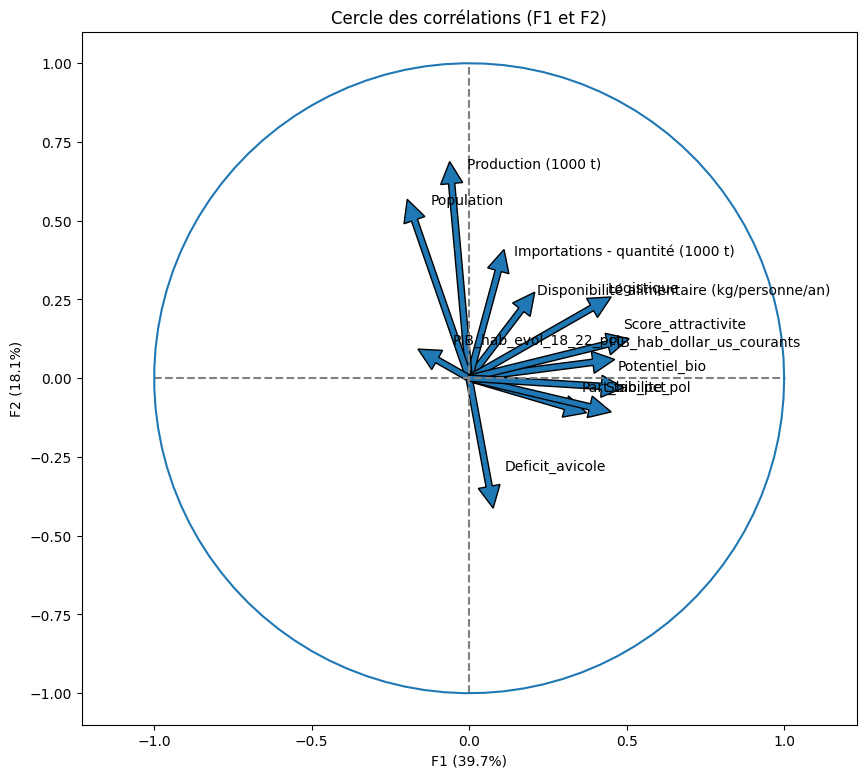

In [34]:
# On essaye pour F1 et F2
x_y = (0,1)
correlation_graph(pca, x_y, features)

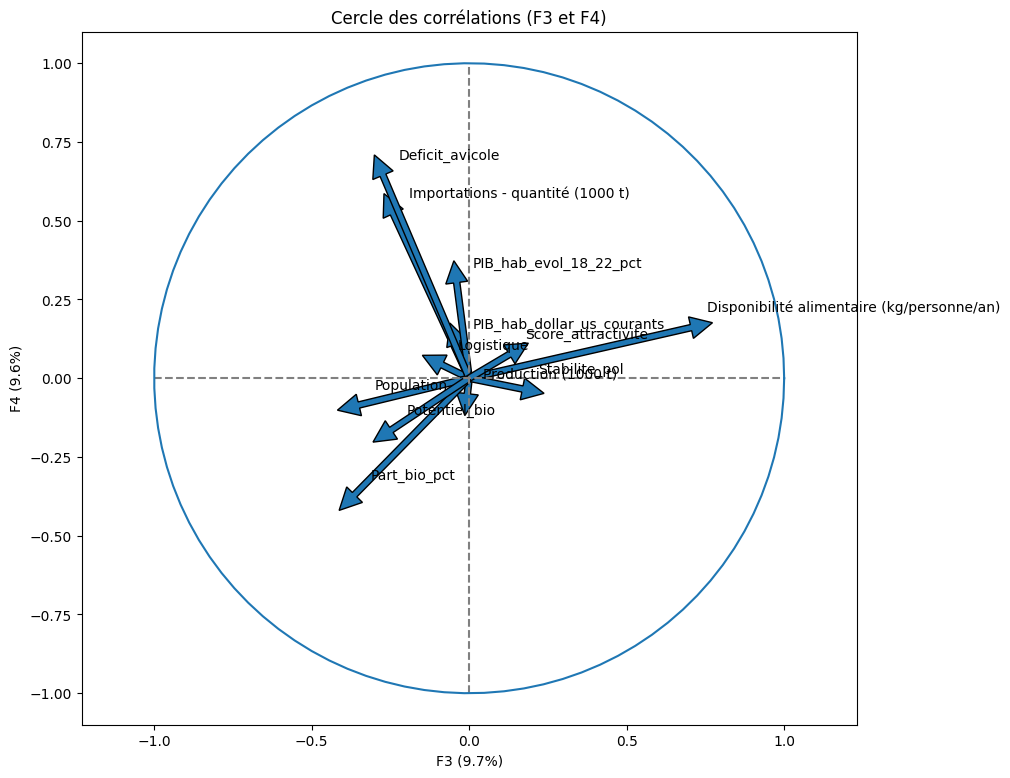

In [35]:
# Pour F3 et F4
correlation_graph(pca, (2,3), features)

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.5 Projection exemple des pays</h3>
</div>

In [36]:
# On va maintenant travailler sur la projection de nos dimensions
# Calculons les coordonnées de nos individus dans le nouvel espace

X_proj = pca.transform(X_scaled) # projection de nos données dans le nouvel espace défini par les composantes principales
X_proj[:5] # Affichage des 5 premières lignes de la matrice de projection

array([[-3.83407981, -1.21876318, -0.92924689, -1.41654785, -2.43323895,
        -0.86674027],
       [-0.67123342,  2.01139723,  0.59159443,  0.04169082, -1.53388757,
        -0.08375107],
       [-0.97385905, -1.38892482,  0.28926635,  1.38426239,  0.70399935,
         0.20712229],
       [-2.4127106 , -0.3774922 , -0.02057676, -1.06313824, -0.33039497,
        -0.629612  ],
       [ 2.7944004 ,  2.33644362, -2.03485877,  0.96938603, -1.35177884,
        -0.14959004]])

In [37]:
# On rappelle que :
x_y

(0, 1)

In [38]:
# On va créer une fonction qui affiche la projection de nos individus sur les plans factoriels, avec différentes options d'affichage (labels, clusters, etc)

def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()



In [39]:
df.columns

Index(['Disponibilité alimentaire (kg/personne/an)',
       'Importations - quantité (1000 t)', 'Production (1000 t)',
       'Part_bio_pct', 'Logistique', 'PIB_hab_dollar_us_courants',
       'Stabilite_pol', 'Population', 'PIB_hab_evol_18_22_pct',
       'Deficit_avicole', 'Score_attractivite', 'Potentiel_bio'],
      dtype='str')

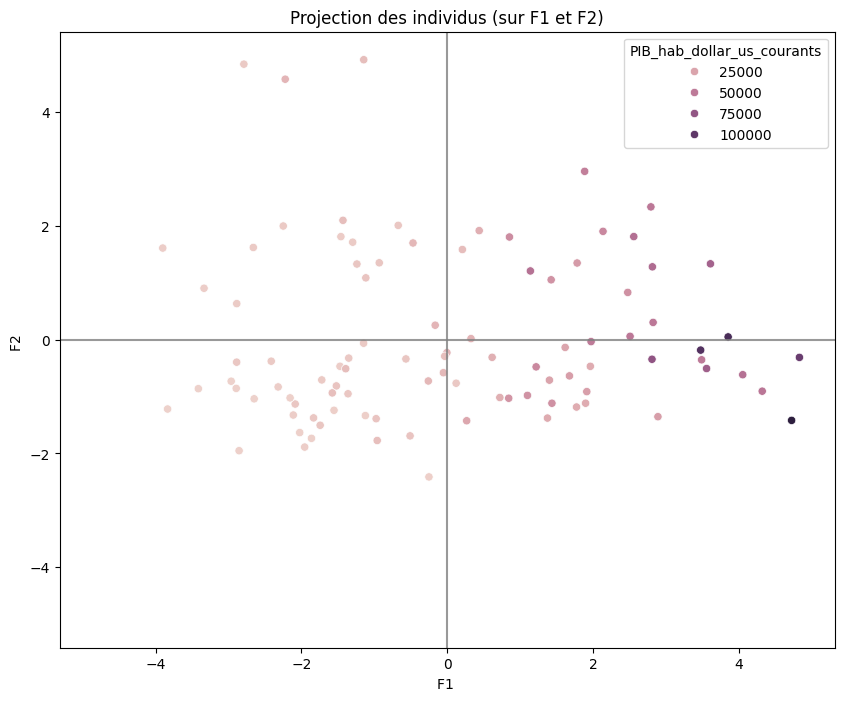

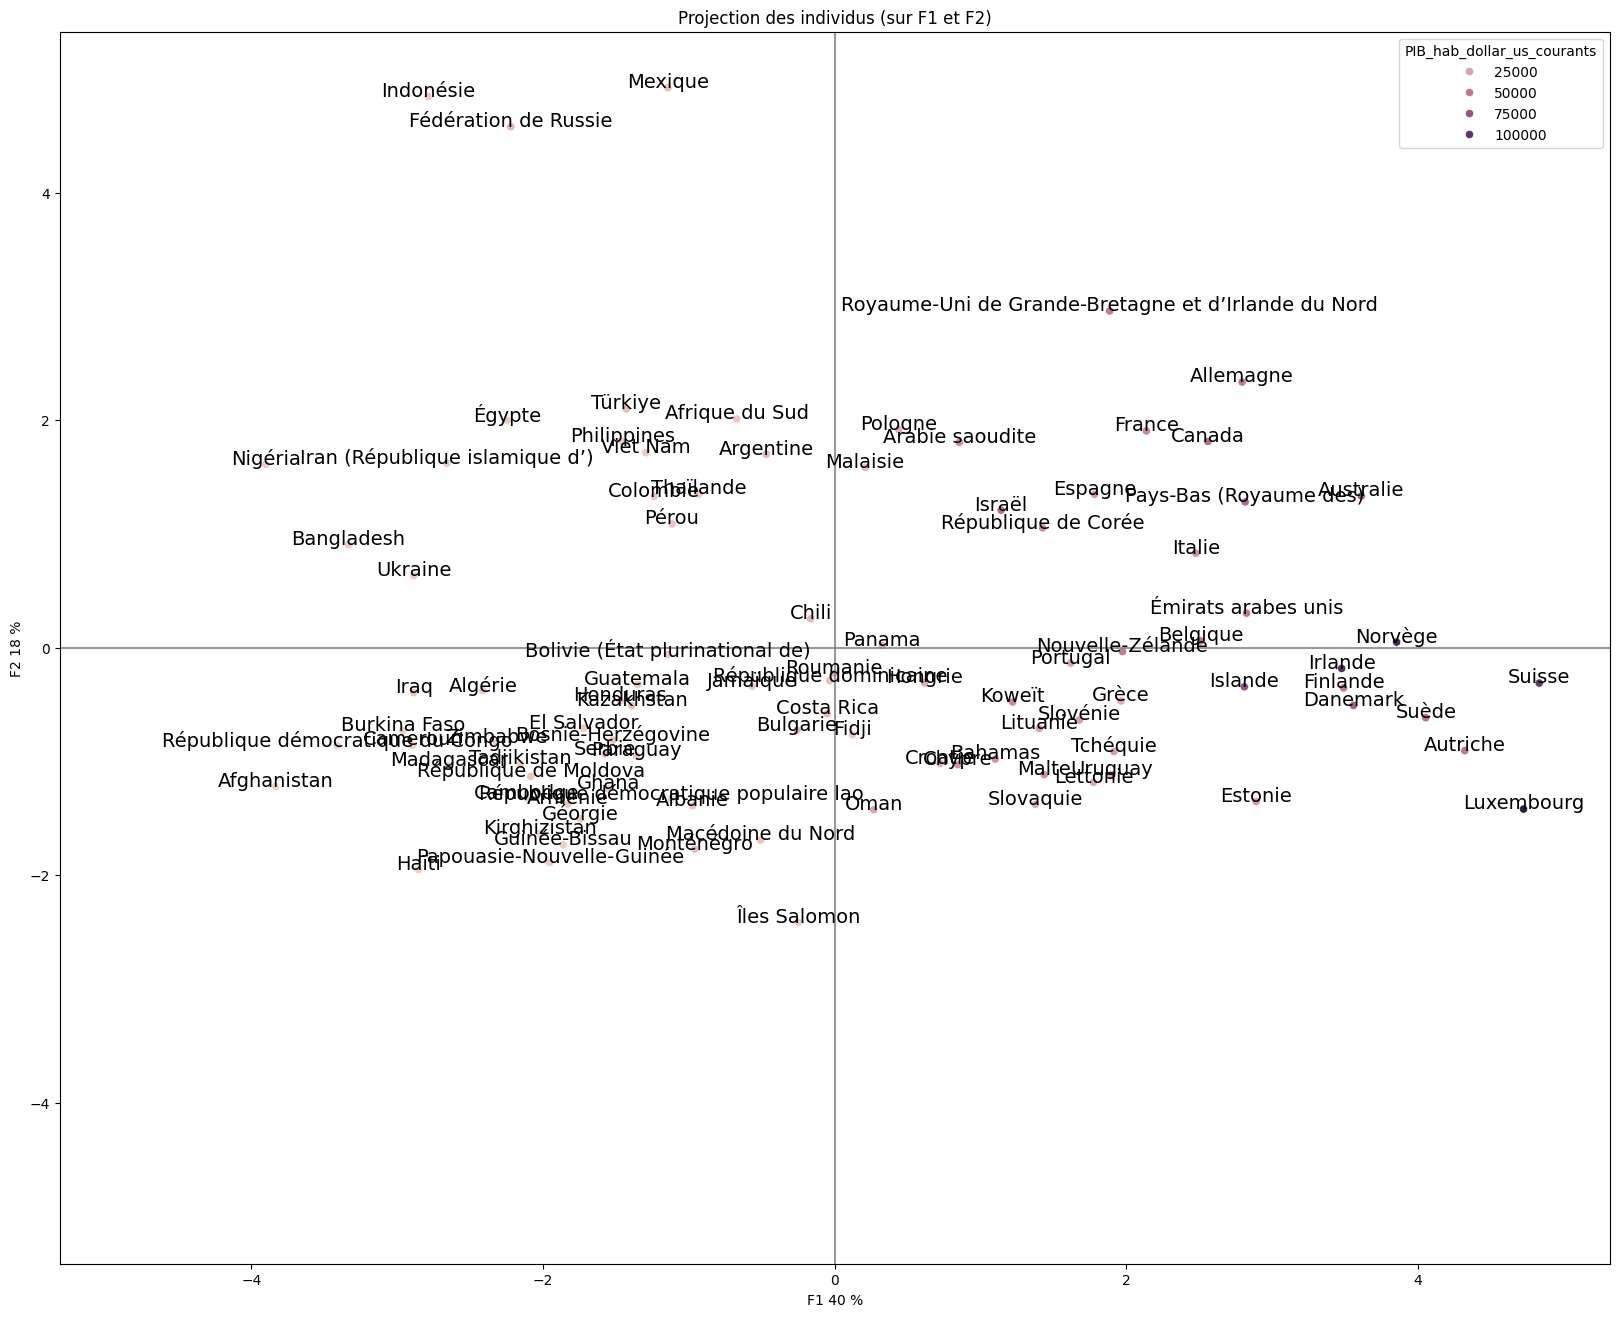

In [40]:
# Version simple avec F1 et F2, les couleurs correspondent au PIB par habitant
x_y = [0,1]
display_factorial_planes(X_proj, x_y, clusters=df['PIB_hab_dollar_us_courants'])
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df['PIB_hab_dollar_us_courants'], marker="o")

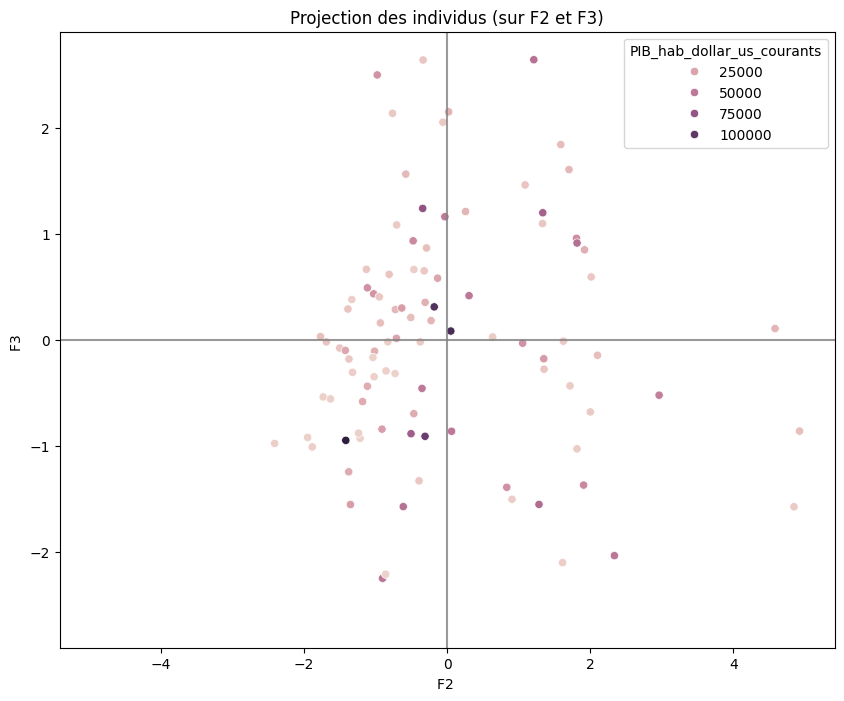

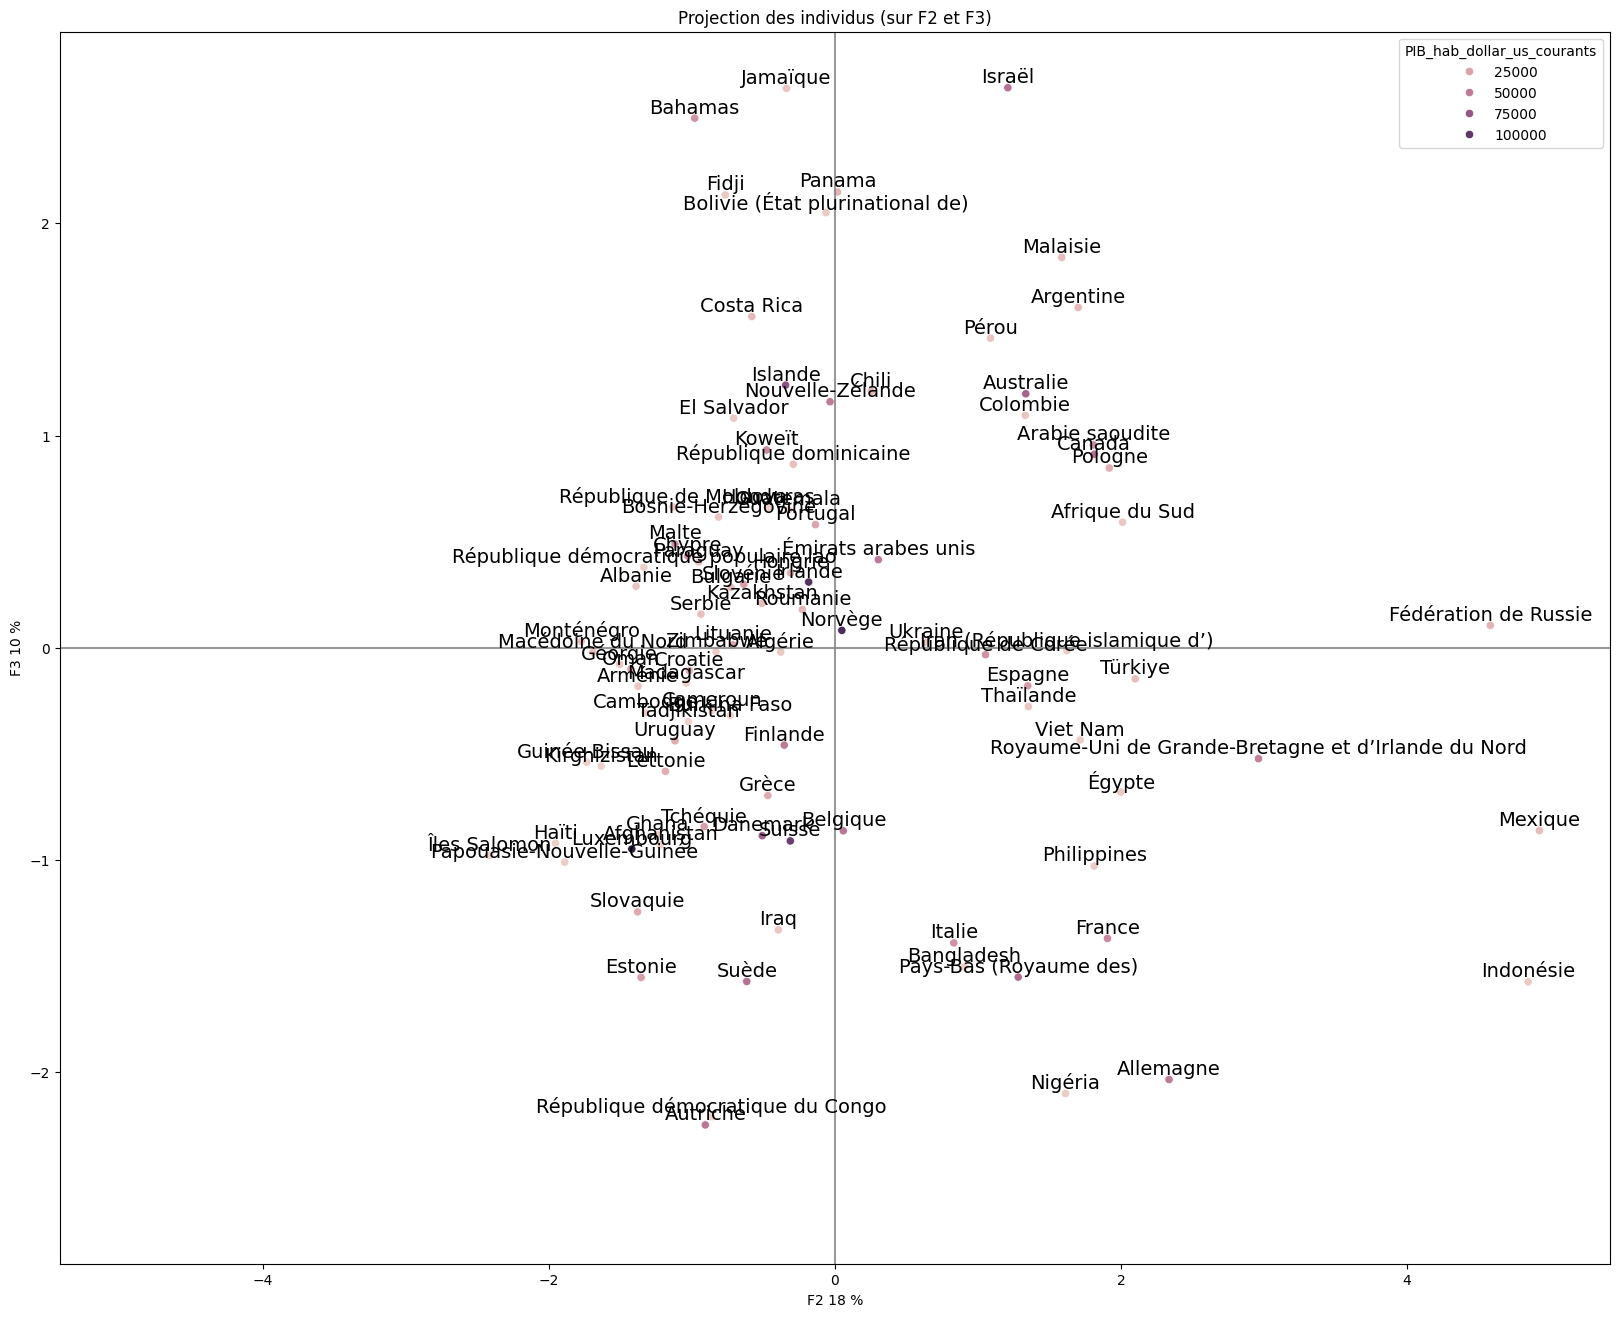

In [41]:
# Essayons avec F2 et F3
x_y = 1,2
display_factorial_planes(X_proj, x_y, clusters=df['PIB_hab_dollar_us_courants'])
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df['PIB_hab_dollar_us_courants'],marker="o")

<div style="border: 1px solid white; background:rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px; color:white ">ETAPE 4 : CLUSTERING</h2>
</div>

In [42]:
# On rappelle df
df

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
Pays,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812
...,...,...,...,...,...,...,...,...,...,...,...,...
Viet Nam,18.11,270.0,1542.0,0.25,3.2,4147.697772,-0.046132,99680655.0,28.7,0.1490,0.3485,0.0200
Zimbabwe,7.69,5.0,118.0,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090
Égypte,17.90,20.0,1999.0,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.1 Méthode N°1 : Classification ascendante hiérarchique (CAH)</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1.1 Dendrogramme</h4>
</div>

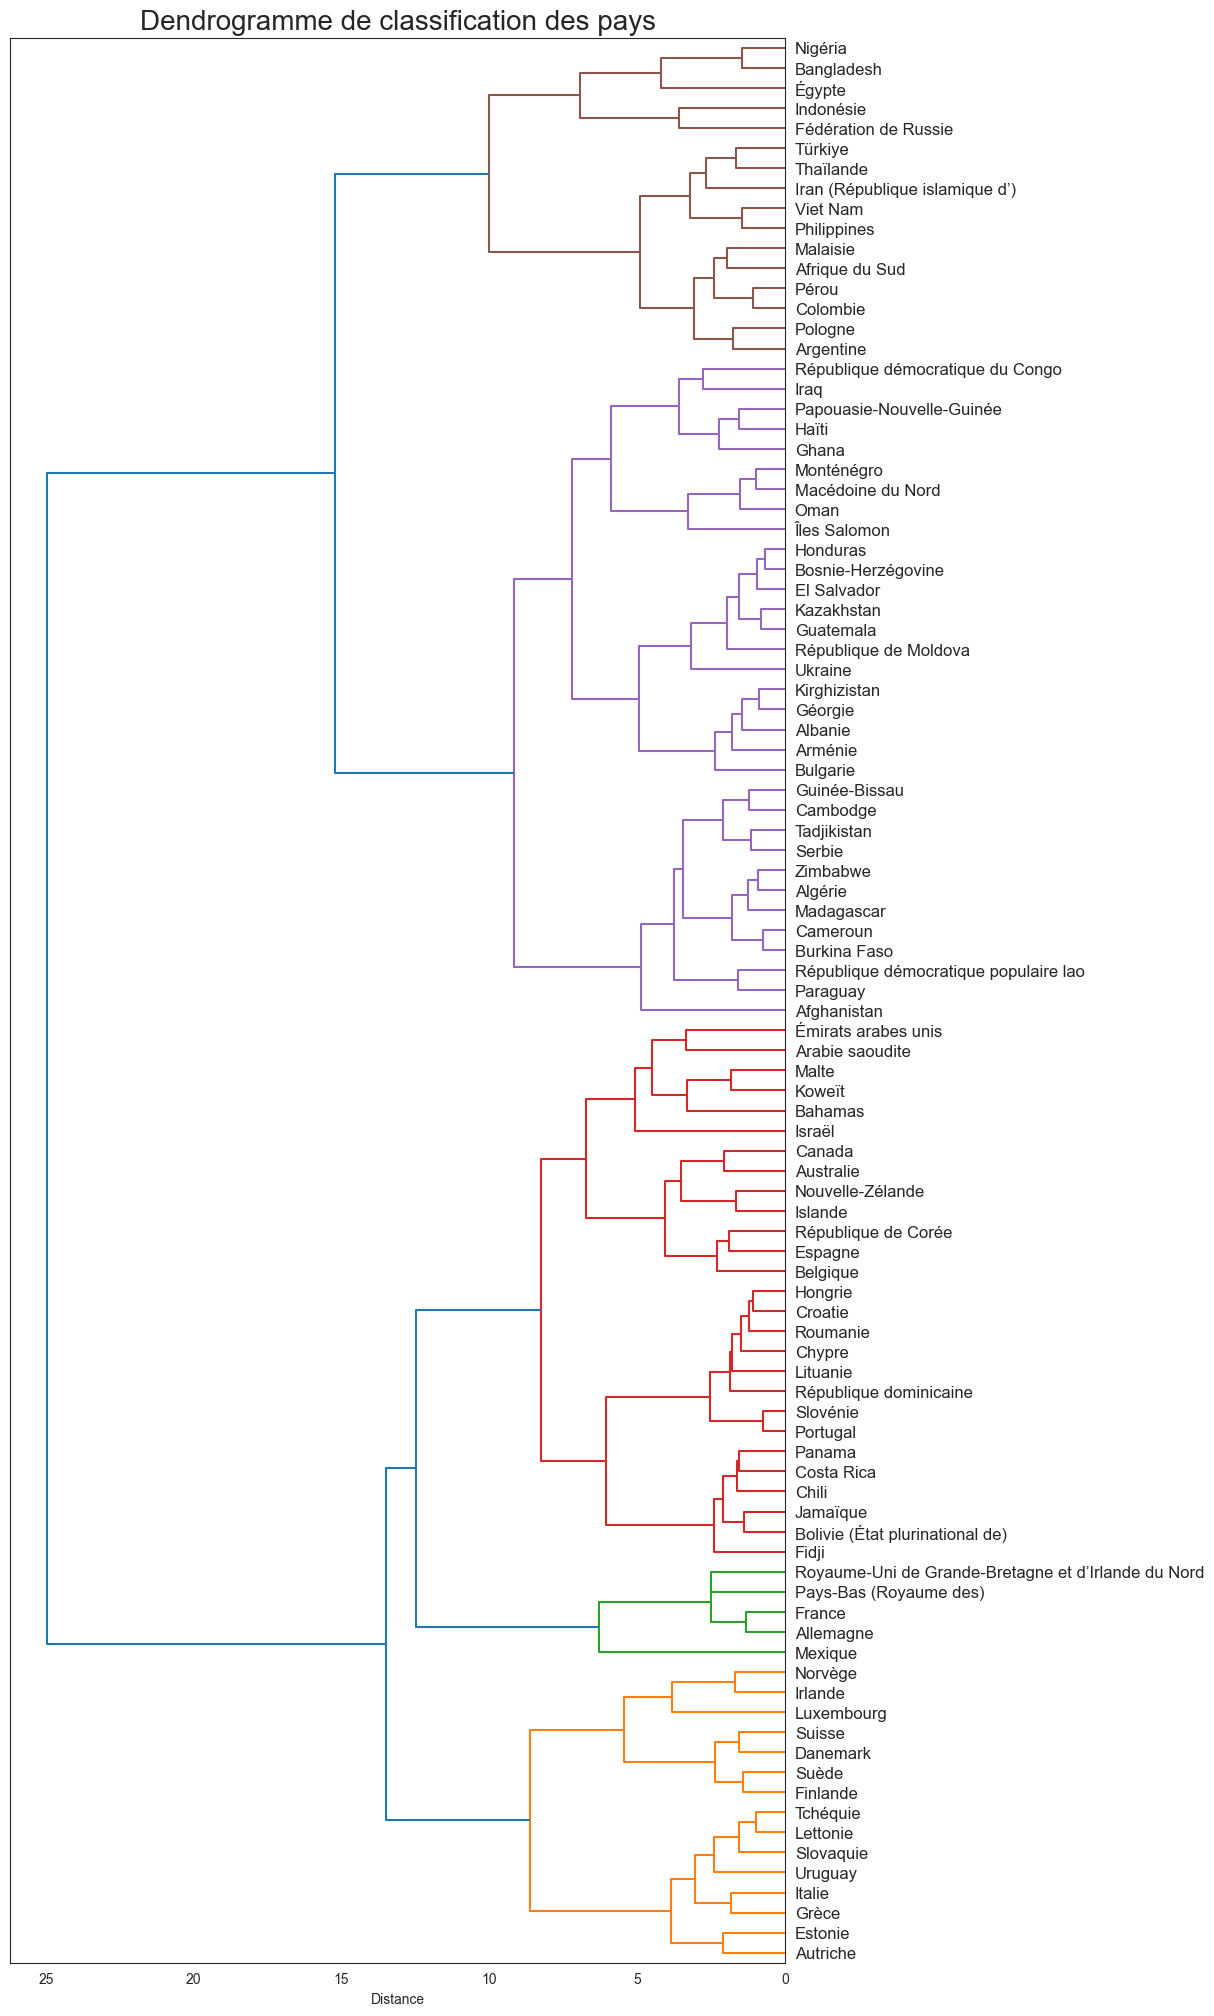

In [43]:
# On va maintenant faire du clustering hiérarchique, afin de regrouper les pays en fonction de leurs caractéristiques communes.

# Produire un arbre de liens hiérarchiques
Z = linkage(X_scaled, method = 'ward', metric='euclidean')

# Méthode de calcul des distances entre les groupes :
# Ward qui est basé sur la moyenne équivalente des distances de variance entre chaque groupe,
# et la métrique euclidienne qui mesure la distance euclidienne entre deux points dans un espace multidimensionnel

# affichage dendrogramme
fig =plt.figure(figsize=(10,25))
sns.set_style('white')
plt.title('Dendrogramme de classification des pays', fontsize=20)
plt.xlabel('Distance')
dendrogram(Z, labels = names, leaf_font_size=12, color_threshold=10, orientation='left')
plt.savefig('data-output/N2-dendrogramme-total.png')
plt.show()

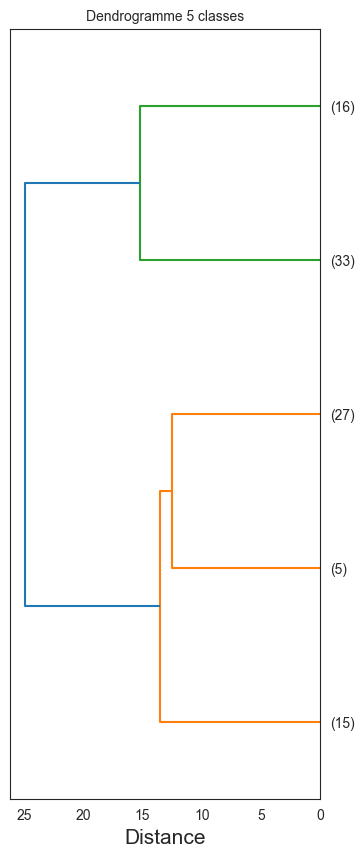

In [44]:
# Division en 5 classes avec le nombre de pays dans chaque classe
fig = plt.figure(figsize=(4,10))
sns.set_style('white')
plt.title('Dendrogramme 5 classes', fontsize=10)
plt.xlabel('Distance', fontsize=15)
dendrogram(Z, labels = df.index, p=5, truncate_mode='lastp', leaf_font_size=10, orientation = "left")
plt.savefig('data-output/N2-dendrogramme-reduit.png')
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1.2 Choix du nombre de clusters</h4>
</div>

In [45]:
# Définissons le nombre de clusters qu'on souhaite
k=5

# On applique ensuite la fonction fclusters de scipy pour définir les clusters
clusters_cah = fcluster(Z, k, criterion='maxclust')
clusters_cah

array([4, 5, 4, 4, 2, 3, 5, 4, 3, 1, 3, 5, 3, 3, 4, 4, 4, 4, 4, 3, 3, 3,
       5, 3, 3, 1, 4, 3, 1, 3, 1, 2, 5, 4, 1, 4, 4, 4, 4, 4, 3, 5, 5, 4,
       1, 3, 3, 1, 3, 4, 4, 3, 1, 3, 1, 4, 4, 5, 3, 2, 4, 5, 1, 3, 4, 3,
       4, 4, 2, 5, 5, 3, 5, 3, 2, 3, 4, 3, 4, 4, 4, 1, 3, 1, 1, 4, 1, 5,
       5, 4, 1, 5, 4, 5, 3, 4], dtype=int32)

In [46]:
# Nouvelle table df_cah_pays_index avec stockage des clusters dans notre dataframe de base
df_cah_pays_index = df.copy()
df_cah_pays_index["cluster_cah"] = clusters_cah
df_cah_pays_index

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_cah
Pays,,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,4
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,5
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,4
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,4
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Viet Nam,18.11,270.0,1542.0,0.25,3.2,4147.697772,-0.046132,99680655.0,28.7,0.1490,0.3485,0.0200,5
Zimbabwe,7.69,5.0,118.0,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090,4
Égypte,17.90,20.0,1999.0,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683,5


In [47]:
# Ici, nous allons créer un tableau de contingence (crosstab) pour visualiser la répartition des pays dans les différents clusters.
crosstab = pd.crosstab(df_cah_pays_index.index, clusters_cah, dropna=False)
crosstab.rename_axis(columns="cluster", index="Pays", inplace=True)
crosstab

cluster,1,2,3,4,5
Pays,,,,,
Afghanistan,0,0,0,1,0
Afrique du Sud,0,0,0,0,1
Albanie,0,0,0,1,0
Algérie,0,0,0,1,0
Allemagne,0,1,0,0,0
...,...,...,...,...,...
Viet Nam,0,0,0,0,1
Zimbabwe,0,0,0,1,0
Égypte,0,0,0,0,1


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1.3 Clusters obtenus</h4>
</div>

In [48]:
# Boucle for pour afficher les pays de chaque cluster
cluster_list_dendrogramme = sorted(crosstab.columns)
for cluster in cluster_list_dendrogramme :
    print(f"Cluster {cluster} :")
    print(crosstab[crosstab[cluster]==1].index.tolist())
    print("\n")

Cluster 1 :
['Autriche', 'Danemark', 'Estonie', 'Finlande', 'Grèce', 'Irlande', 'Italie', 'Lettonie', 'Luxembourg', 'Norvège', 'Slovaquie', 'Suisse', 'Suède', 'Tchéquie', 'Uruguay']


Cluster 2 :
['Allemagne', 'France', 'Mexique', 'Pays-Bas (Royaume des)', 'Royaume-Uni de Grande-Bretagne et d’Irlande du Nord']


Cluster 3 :
['Arabie saoudite', 'Australie', 'Bahamas', 'Belgique', 'Bolivie (État plurinational de)', 'Canada', 'Chili', 'Chypre', 'Costa Rica', 'Croatie', 'Espagne', 'Fidji', 'Hongrie', 'Islande', 'Israël', 'Jamaïque', 'Koweït', 'Lituanie', 'Malte', 'Nouvelle-Zélande', 'Panama', 'Portugal', 'Roumanie', 'République de Corée', 'République dominicaine', 'Slovénie', 'Émirats arabes unis']


Cluster 4 :
['Afghanistan', 'Albanie', 'Algérie', 'Arménie', 'Bosnie-Herzégovine', 'Bulgarie', 'Burkina Faso', 'Cambodge', 'Cameroun', 'El Salvador', 'Ghana', 'Guatemala', 'Guinée-Bissau', 'Géorgie', 'Haïti', 'Honduras', 'Iraq', 'Kazakhstan', 'Kirghizistan', 'Macédoine du Nord', 'Madagascar', 

In [49]:
# Boucle for pour afficher les pays de chaque cluster, 1 cluster, 1 tableau (autre façon d'afficher les données)
for cluster in cluster_list_dendrogramme :
    print(f"Cluster {cluster} :")
    display(crosstab[crosstab[cluster]==1].index.to_frame().reset_index(drop=True))
    print("\n")

Cluster 1 :


,Pays
0,Autriche
1,Danemark
2,Estonie
3,Finlande
4,Grèce
5,Irlande
6,Italie
7,Lettonie
8,Luxembourg
9,Norvège




Cluster 2 :


,Pays
0,Allemagne
1,France
2,Mexique
3,Pays-Bas (Royaume des)
4,Royaume-Uni de Grande-Bretagne et d’Irlande du...




Cluster 3 :


,Pays
0,Arabie saoudite
1,Australie
2,Bahamas
3,Belgique
4,Bolivie (État plurinational de)
5,Canada
6,Chili
7,Chypre
8,Costa Rica
9,Croatie




Cluster 4 :


,Pays
0,Afghanistan
1,Albanie
2,Algérie
3,Arménie
4,Bosnie-Herzégovine
5,Bulgarie
6,Burkina Faso
7,Cambodge
8,Cameroun
9,El Salvador




Cluster 5 :


,Pays
0,Afrique du Sud
1,Argentine
2,Bangladesh
3,Colombie
4,Fédération de Russie
5,Indonésie
6,Iran (République islamique d’)
7,Malaisie
8,Nigéria
9,Philippines


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1.4 Analyse des clusters CAH</h4>
</div>

In [50]:
df_cah_flat = df_cah_pays_index.reset_index()
df_cah_flat

,Pays,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_cah
0,Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,4
1,Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,5
2,Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,4
3,Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,4
4,Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Viet Nam,18.11,270.0,1542.0,0.25,3.2,4147.697772,-0.046132,99680655.0,28.7,0.1490,0.3485,0.0200,5
92,Zimbabwe,7.69,5.0,118.0,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090,4
93,Égypte,17.90,20.0,1999.0,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683,5
94,Émirats arabes unis,47.53,638.0,47.0,1.38,4.1,50759.758923,0.744183,10074977.0,7.7,0.9314,0.6787,0.2297,3


In [51]:
# Pour rappel
display(cols)
print(len(cols))

['Disponibilité alimentaire (kg/personne/an)',
 'Importations - quantité (1000 t)',
 'Production (1000 t)',
 'Part_bio_pct',
 'Logistique',
 'PIB_hab_dollar_us_courants',
 'Stabilite_pol',
 'Population',
 'PIB_hab_evol_18_22_pct',
 'Deficit_avicole',
 'Score_attractivite',
 'Potentiel_bio']

12


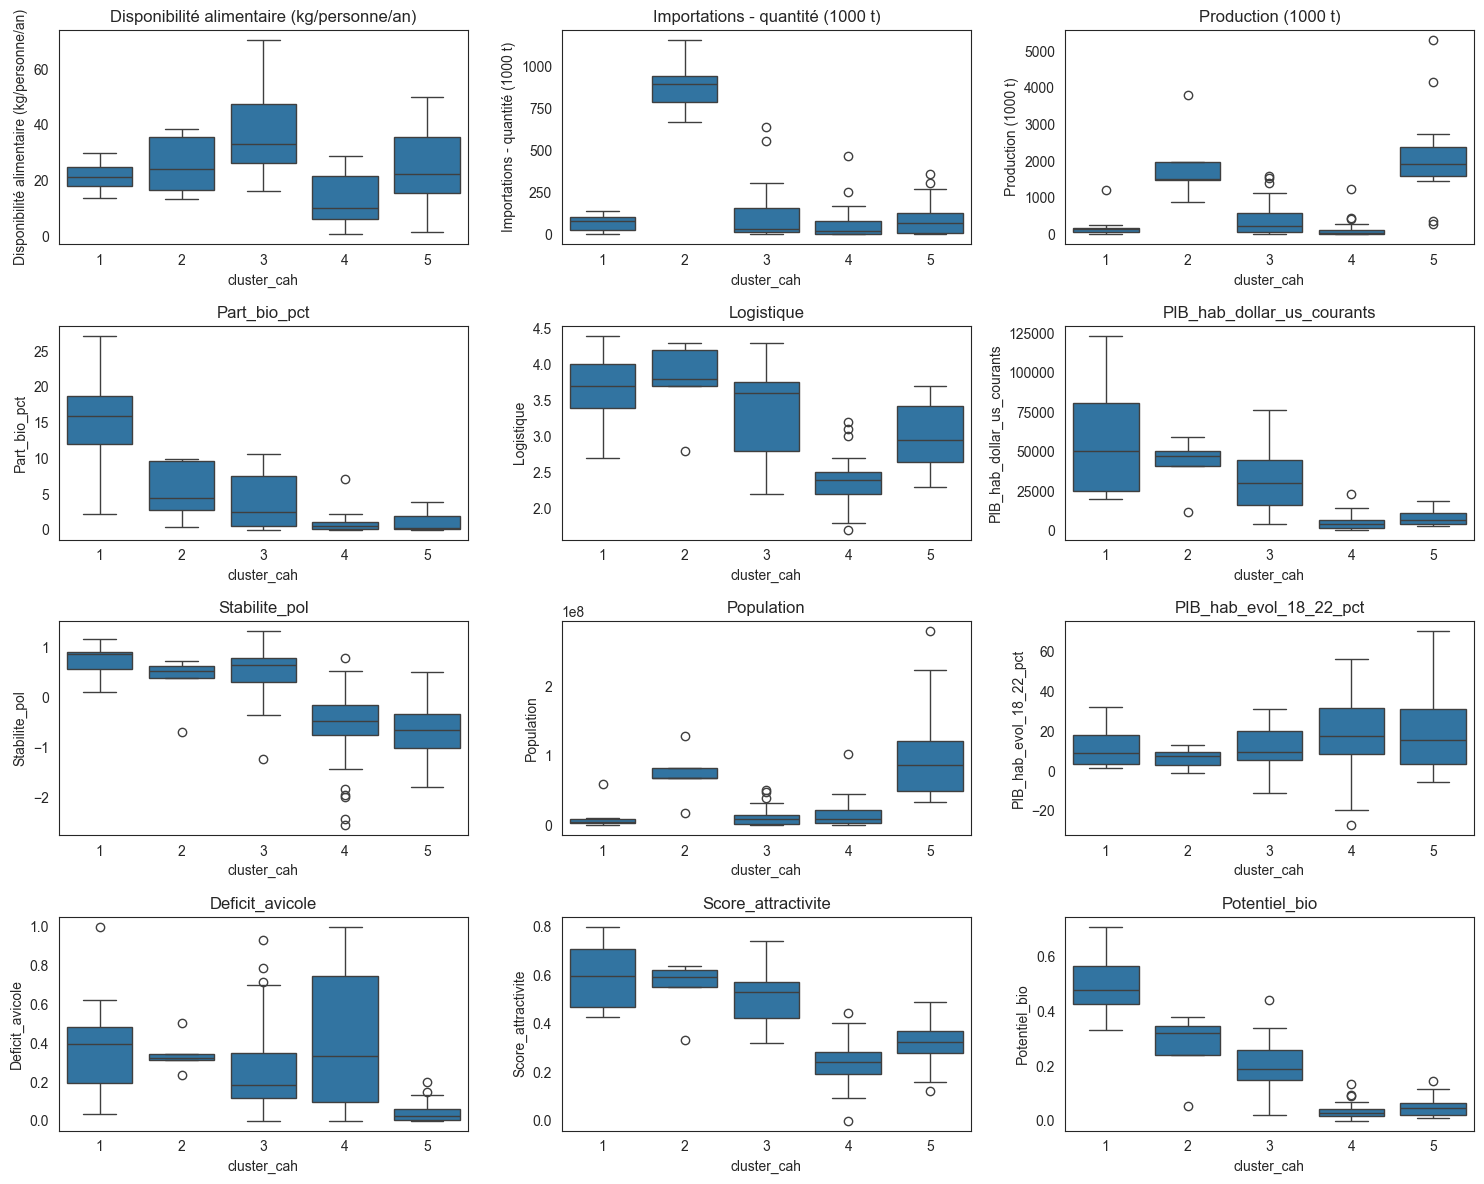

In [52]:
# Création des boxplots par cluster cah pour toutes les variables

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
sns.set(style="whitegrid")

for idx, var in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_cah_flat, x='cluster_cah', y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.savefig("data-output/N2-boxplot_cluster_cah.png", dpi=300, bbox_inches='tight')
plt.show()

In [53]:
# Création du dataframe des moyennes
df_cah_moyenne = df_cah_flat.drop(columns="Pays").groupby('cluster_cah').mean().round(2)
df_cah_moyenne

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
cluster_cah,,,,,,,,,,,,
1,21.72,69.73,188.60,14.86,3.67,55566.02,0.76,9.550776e+06,11.69,0.38,0.60,0.50
2,25.70,891.60,1930.60,5.46,3.76,41816.26,0.32,7.305607e+07,6.54,0.34,0.55,0.27
3,37.47,113.59,440.63,3.96,3.33,31625.58,0.52,1.274829e+07,11.73,0.26,0.52,0.20
4,13.56,58.12,127.00,0.80,2.39,5134.84,-0.61,1.716516e+07,17.29,0.42,0.23,0.03
5,25.50,101.00,2116.31,1.05,3.01,7849.80,-0.65,1.032889e+08,19.09,0.05,0.32,0.05


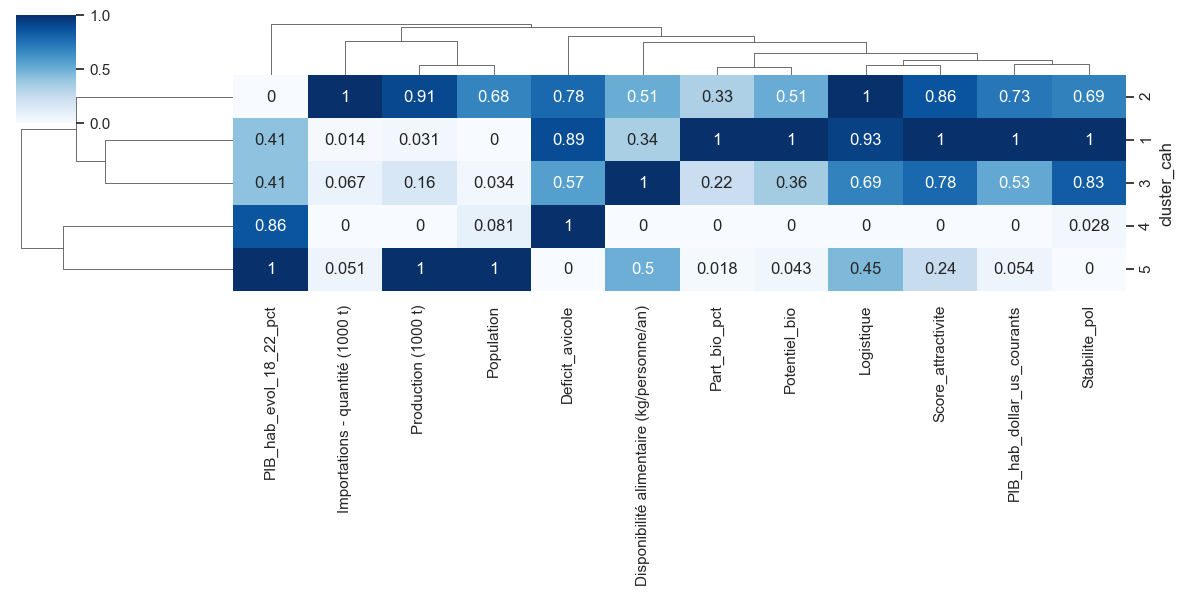

In [54]:
# Clustermap entr clusters et variables
sns.clustermap(df_cah_moyenne, figsize=(12, 6), annot=True,
               standard_scale=1, cmap='Blues')
plt.savefig("data-output/N2-clustermap_cah.png")
plt.show()

Cluster 1 : Pays stables développés économiquement avec fort intérêt pour le bio, peu de production et peu d'importations.

Cluster 2 : Pays stables, surtout importateurs mais également producteurs, avec une plus grande population.

Cluster 3 : Pays stables, les plus gros consommateurs de volaille, attirance pour le bio => Regarder plutôt dans ce cluster.

Cluster 4 : Les moins consommateurs, les moins producteurs, ceux qui n'ont pas encore développé la partie bio (les moins attractifs).

Cluster 5 : Bons consommateurs, plus gros producteurs mais stabilité politique plus faible.


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1.5 Stockage clusters intéressants</h4>
</div>

In [55]:
# df_cah cluster 3, trié par ordre décroissant score_attractivite, garder uniquement pays et score attractivité
df_cah_cluster3 = df_cah_flat[df_cah_flat["cluster_cah"]==3][["Pays", "Score_attractivite", "cluster_cah"]].sort_values(by="Score_attractivite", ascending=False).reset_index(drop=True)
df_cah_cluster3

,Pays,Score_attractivite,cluster_cah
0,Australie,0.7393,3
1,Islande,0.7026,3
2,Canada,0.7006,3
3,Émirats arabes unis,0.6787,3
4,Nouvelle-Zélande,0.6374,3
5,Belgique,0.6003,3
6,Israël,0.5752,3
7,République de Corée,0.5681,3
8,Malte,0.5620,3
9,Koweït,0.5574,3


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.2 Méthode N°2 : K-means</h3>
</div>

In [56]:
# Dans cette section, on va utiliser la méthode K-means pour faire du clustering, et comparer les résultats avec le clustering hiérarchique que nous avons fait précédemment.

In [57]:
# Rappel du dataframe
df.head()

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
Pays,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.1 Test avec nombre défini de cluster</h4>
</div>

In [58]:
# On instancie notre estimateur, c'est-à-dire notre algorithme de clustering K-means, en lui précisant le nombre de clusters que nous souhaitons obtenir (ici 3)
kmeans = KMeans(n_clusters=5)

In [59]:
# On l'entraîne sur les données
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [60]:
# On calcule son inertie (c'est une mesure de la qualité du clustering)
kmeans.inertia_

535.4773032822145

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.2 Méthode du coude</h4>
</div>

In [61]:
# Définissons une liste vide dans laquelle nous allons stocker les inerties
inertias = []

In [62]:
# Définissons ensuite la liste du nombre de clusters que nous allons tester
k_list = range(1,10)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [63]:
# Pour chaque nombre de clusters, on entraîne un kmeans spécifique et on stocke son inertie
for i in k_list :
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

In [64]:
# Nous obtenons la liste des inerties suivantes :
inertias

[1152.0,
 809.3177232710079,
 692.396439916166,
 637.7607212029618,
 559.1535621554095,
 492.3355986588577,
 462.45758360790654,
 420.3675500437134,
 424.5330932290978]

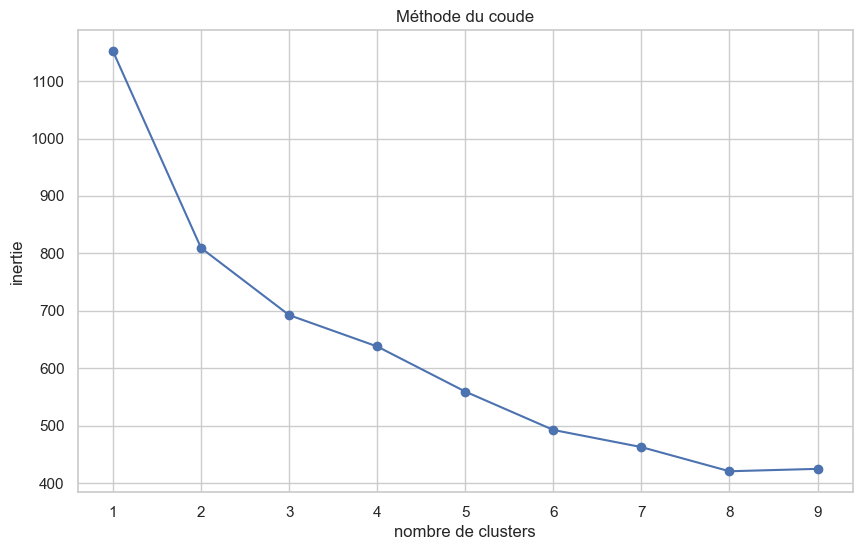

In [65]:
# Affichage du résultat
plt.figure(figsize=(10,6))
plt.plot(k_list, inertias, marker="o")
plt.xlabel("nombre de clusters")
plt.ylabel("inertie")
plt.title("Méthode du coude")
plt.savefig("data-output/N2-methode_du_coude.png", bbox_inches="tight")
plt.show(block=False)

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.3 Clusters obtenus</h4>
</div>

In [66]:
# On va regarder les clusters obtenus avec kmeans
# On entraîne à nouveau un kmeans avec un nombre défini de clusters, une grande valeur de n_init pour éviter les problèmes de convergence, et un random_state défini pour la reproductibilité
kmeans = KMeans(n_clusters=5, random_state=42, n_init=50)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [67]:
# Voici les clusters obtenus
kmeans.labels_

array([3, 2, 3, 3, 4, 4, 2, 3, 1, 1, 2, 0, 1, 2, 3, 2, 3, 3, 3, 1, 2, 2,
       2, 2, 2, 1, 3, 1, 1, 2, 1, 4, 0, 3, 1, 3, 3, 3, 3, 3, 2, 0, 0, 3,
       1, 1, 2, 1, 2, 3, 3, 2, 1, 1, 1, 3, 3, 2, 2, 4, 3, 0, 1, 1, 2, 2,
       3, 3, 4, 0, 2, 2, 2, 2, 4, 2, 3, 2, 3, 3, 3, 1, 1, 1, 1, 3, 1, 0,
       0, 3, 1, 0, 3, 0, 4, 3], dtype=int32)

In [68]:
dd = {i:j for i,j in enumerate(list("abcde"))} # On crée un dictionnaire pour remplacer les numéros de clusters par des lettres, pour une lisibilité différente de CAH

In [69]:
labels = [dd[i] for i in kmeans.labels_] # On remplace les numéros de cluster par des lettres
labels[:5] # Affichage des 5 premières étiquettes de cluster

['d', 'c', 'd', 'd', 'e']

In [70]:
df_kmeans_pays_index = df.copy() # On crée une copie de notre dataframe pour y ajouter les clusters obtenus avec kmeans
df_kmeans_pays_index["cluster_kmeans"] = labels
df_kmeans_pays_index

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_kmeans
Pays,,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,d
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,c
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,d
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,d
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,e
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Viet Nam,18.11,270.0,1542.0,0.25,3.2,4147.697772,-0.046132,99680655.0,28.7,0.1490,0.3485,0.0200,a
Zimbabwe,7.69,5.0,118.0,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090,d
Égypte,17.90,20.0,1999.0,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683,a


In [71]:
# Afficher les pays de chaque cluster
df_cluster_kmeans = pd.DataFrame({ "Pays" : df_kmeans_pays_index.index, "cluster_kmeans" : labels})
df_cluster_kmeans

,Pays,cluster_kmeans
0,Afghanistan,d
1,Afrique du Sud,c
2,Albanie,d
3,Algérie,d
4,Allemagne,e
...,...,...
91,Viet Nam,a
92,Zimbabwe,d
93,Égypte,a
94,Émirats arabes unis,e


In [72]:
cluster_list_kmeans = sorted(df_cluster_kmeans["cluster_kmeans"].unique())

In [73]:
# Boucle for pour afficher les pays de chaque cluster
for cluster in cluster_list_kmeans :
    print(f"Cluster {cluster} :")
    print(df_cluster_kmeans[df_cluster_kmeans["cluster_kmeans"]==cluster]["Pays"].tolist())
    print("\n")

Cluster a :
['Bangladesh', 'Fédération de Russie', 'Indonésie', 'Iran (République islamique d’)', 'Nigéria', 'Philippines', 'Thaïlande', 'Türkiye', 'Viet Nam', 'Égypte']


Cluster b :
['Australie', 'Autriche', 'Belgique', 'Canada', 'Danemark', 'Espagne', 'Estonie', 'Finlande', 'Grèce', 'Irlande', 'Islande', 'Italie', 'Lettonie', 'Lituanie', 'Luxembourg', 'Norvège', 'Nouvelle-Zélande', 'Slovaquie', 'Slovénie', 'Suisse', 'Suède', 'Tchéquie', 'Uruguay']


Cluster c :
['Afrique du Sud', 'Argentine', 'Bahamas', 'Bolivie (État plurinational de)', 'Bulgarie', 'Chili', 'Chypre', 'Colombie', 'Costa Rica', 'Croatie', 'Fidji', 'Hongrie', 'Israël', 'Jamaïque', 'Koweït', 'Malaisie', 'Malte', 'Oman', 'Panama', 'Pologne', 'Portugal', 'Pérou', 'Roumanie', 'République de Corée', 'République dominicaine']


Cluster d :
['Afghanistan', 'Albanie', 'Algérie', 'Arménie', 'Bosnie-Herzégovine', 'Burkina Faso', 'Cambodge', 'Cameroun', 'El Salvador', 'Ghana', 'Guatemala', 'Guinée-Bissau', 'Géorgie', 'Haïti', 'H

In [74]:
# Boucle for pour afficher les pays de chaque cluster, 1 cluster, 1 tableau (autre façon d'afficher les données)
for cluster in cluster_list_kmeans :
    print(f"Cluster {cluster} :")
    display(df_cluster_kmeans[df_cluster_kmeans["cluster_kmeans"]==cluster]["Pays"].to_frame().reset_index(drop=True))
    print("\n")


Cluster a :


,Pays
0,Bangladesh
1,Fédération de Russie
2,Indonésie
3,Iran (République islamique d’)
4,Nigéria
5,Philippines
6,Thaïlande
7,Türkiye
8,Viet Nam
9,Égypte




Cluster b :


,Pays
0,Australie
1,Autriche
2,Belgique
3,Canada
4,Danemark
5,Espagne
6,Estonie
7,Finlande
8,Grèce
9,Irlande




Cluster c :


,Pays
0,Afrique du Sud
1,Argentine
2,Bahamas
3,Bolivie (État plurinational de)
4,Bulgarie
5,Chili
6,Chypre
7,Colombie
8,Costa Rica
9,Croatie




Cluster d :


,Pays
0,Afghanistan
1,Albanie
2,Algérie
3,Arménie
4,Bosnie-Herzégovine
5,Burkina Faso
6,Cambodge
7,Cameroun
8,El Salvador
9,Ghana




Cluster e :


,Pays
0,Allemagne
1,Arabie saoudite
2,France
3,Mexique
4,Pays-Bas (Royaume des)
5,Royaume-Uni de Grande-Bretagne et d’Irlande du...
6,Émirats arabes unis


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.4 Graphique pairplot</h4>
</div>

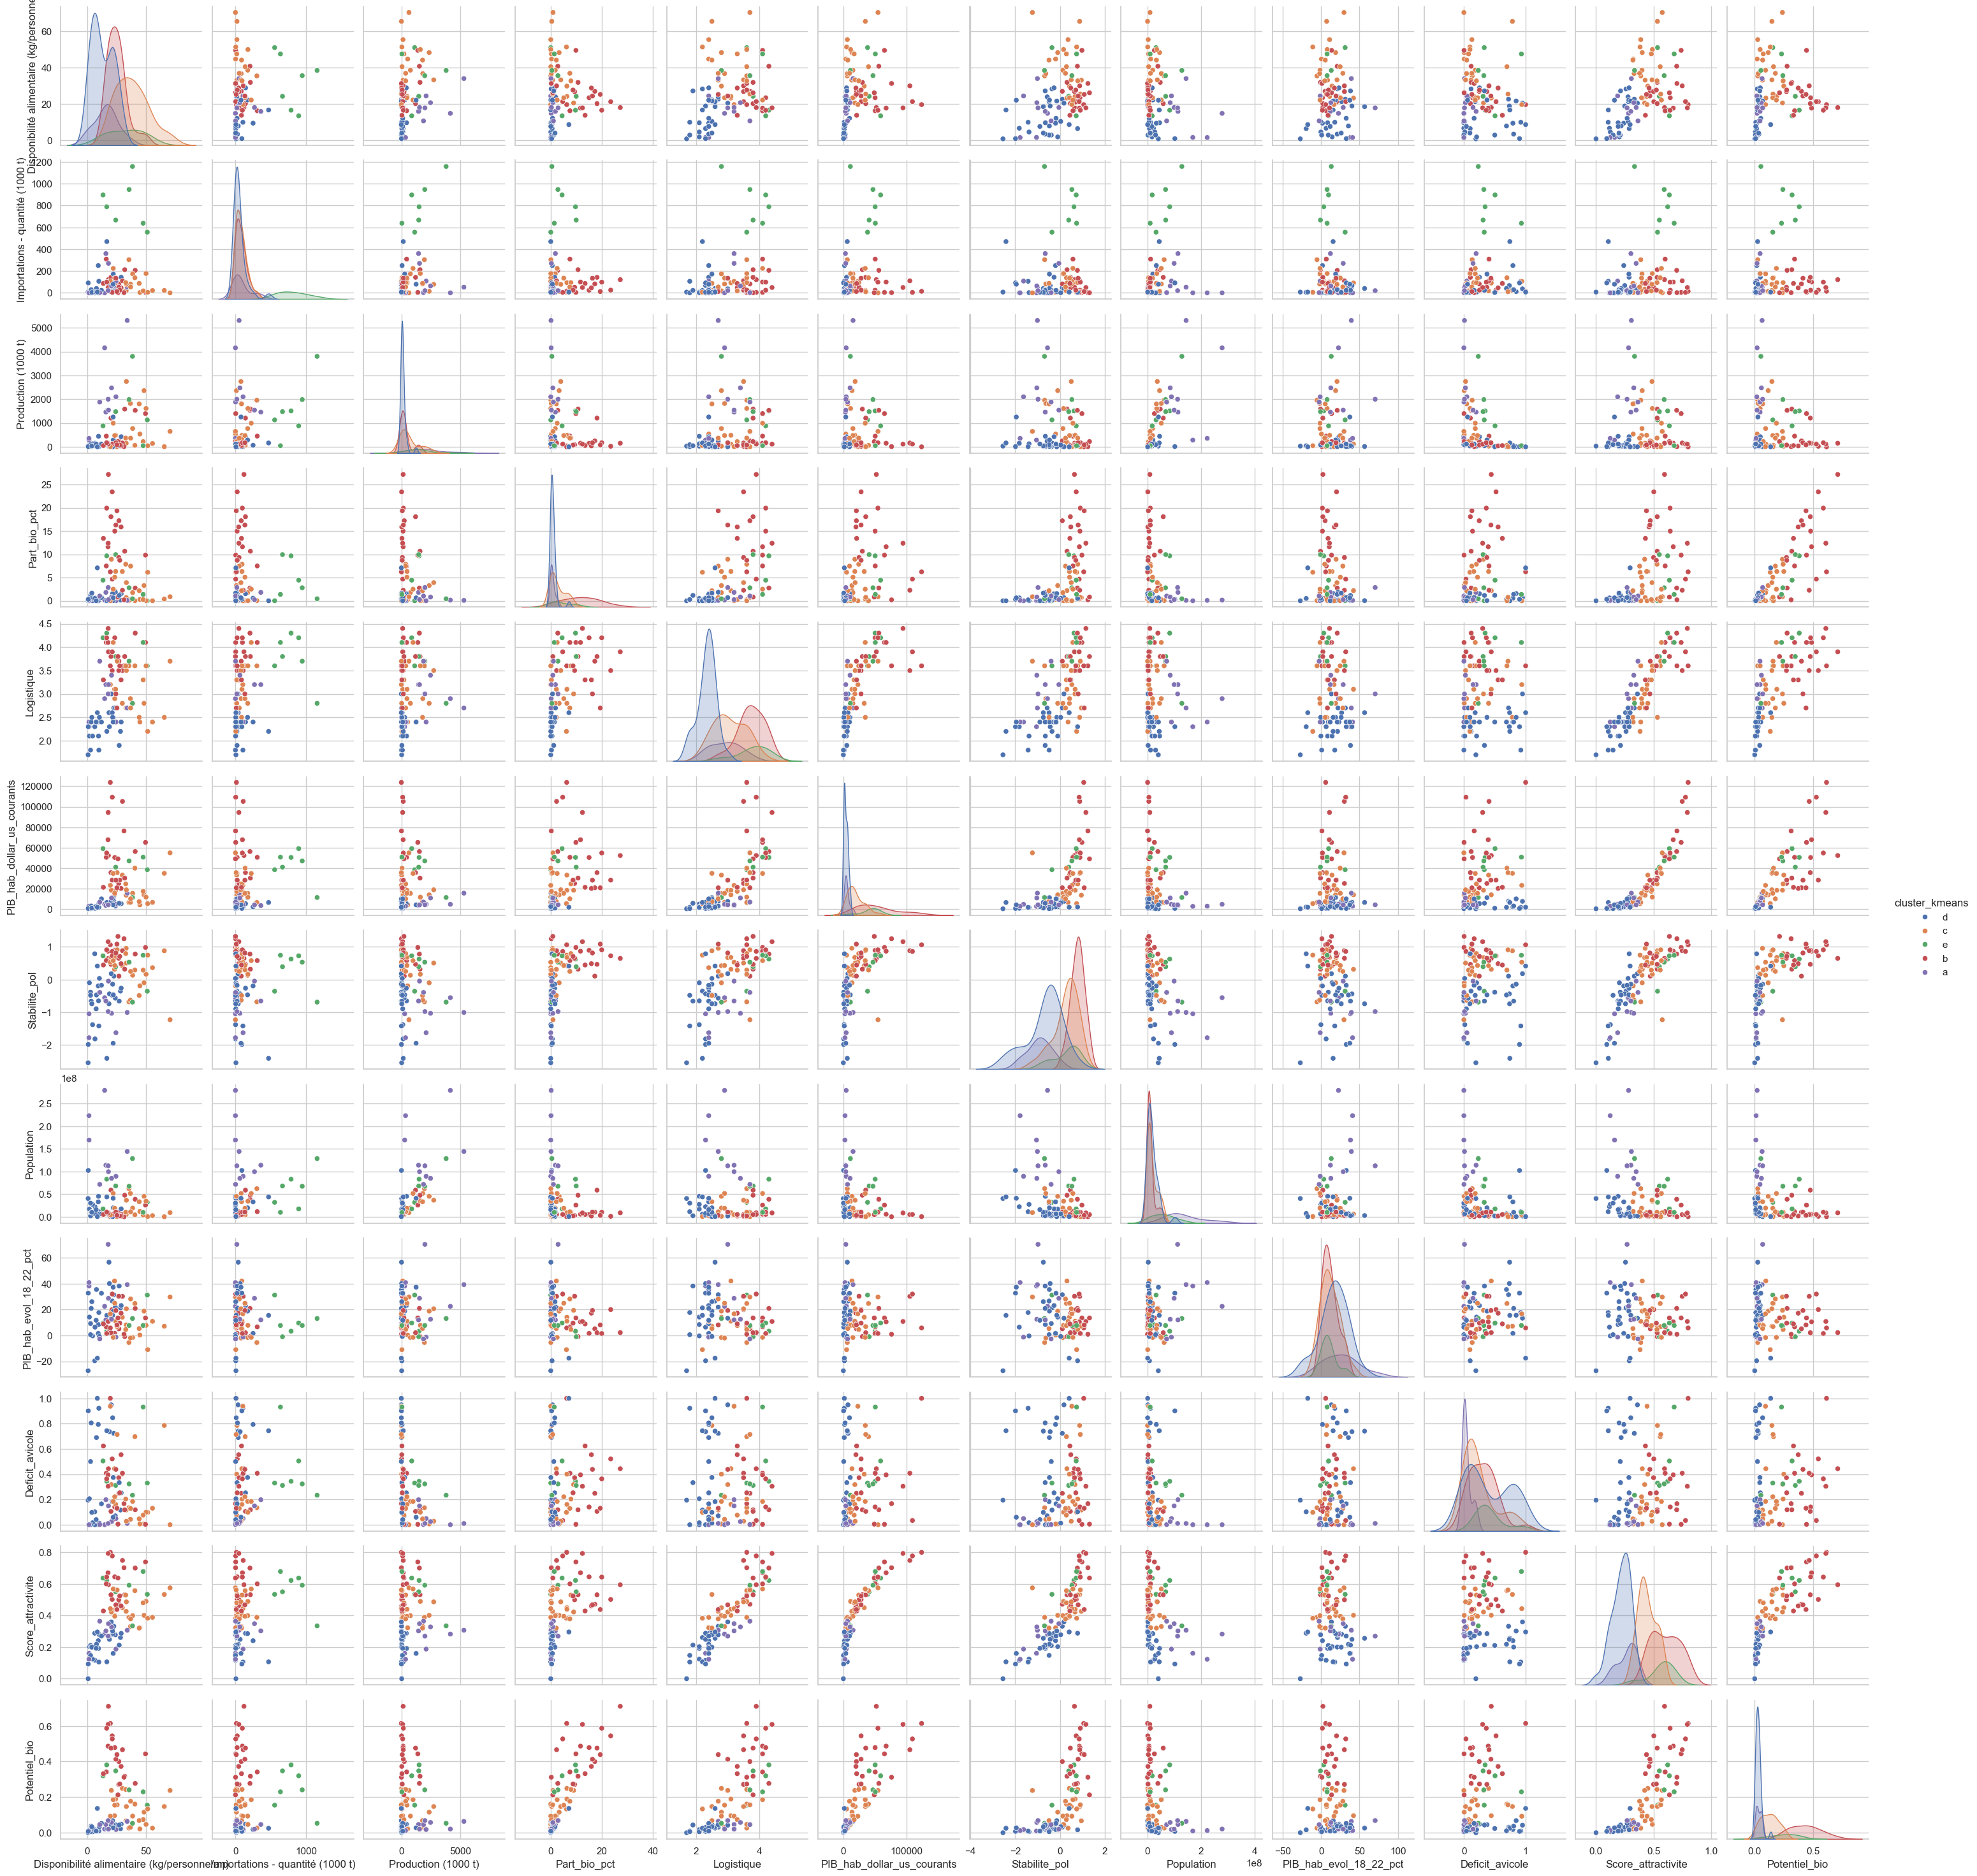

In [75]:
sns.pairplot(df_kmeans_pays_index, hue="cluster_kmeans") # Affichage de la matrice de scatterplots pour visualiser les clusters obtenus avec kmeans
plt.savefig("data-output/N2-pairplot_kmeans.png", bbox_inches="tight")

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.5 Analyse des clusters Kmeans</h4>
</div>

In [76]:
df_kmeans_flat = df_kmeans_pays_index.reset_index()
df_kmeans_flat

,Pays,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_kmeans
0,Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,d
1,Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,c
2,Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,d
3,Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,d
4,Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Viet Nam,18.11,270.0,1542.0,0.25,3.2,4147.697772,-0.046132,99680655.0,28.7,0.1490,0.3485,0.0200,a
92,Zimbabwe,7.69,5.0,118.0,0.01,2.4,2536.400502,-0.894974,16069056.0,11.7,0.0407,0.1924,0.0090,d
93,Égypte,17.90,20.0,1999.0,2.86,3.0,4233.307837,-0.978701,112618250.0,70.4,0.0099,0.2694,0.0683,a
94,Émirats arabes unis,47.53,638.0,47.0,1.38,4.1,50759.758923,0.744183,10074977.0,7.7,0.9314,0.6787,0.2297,e


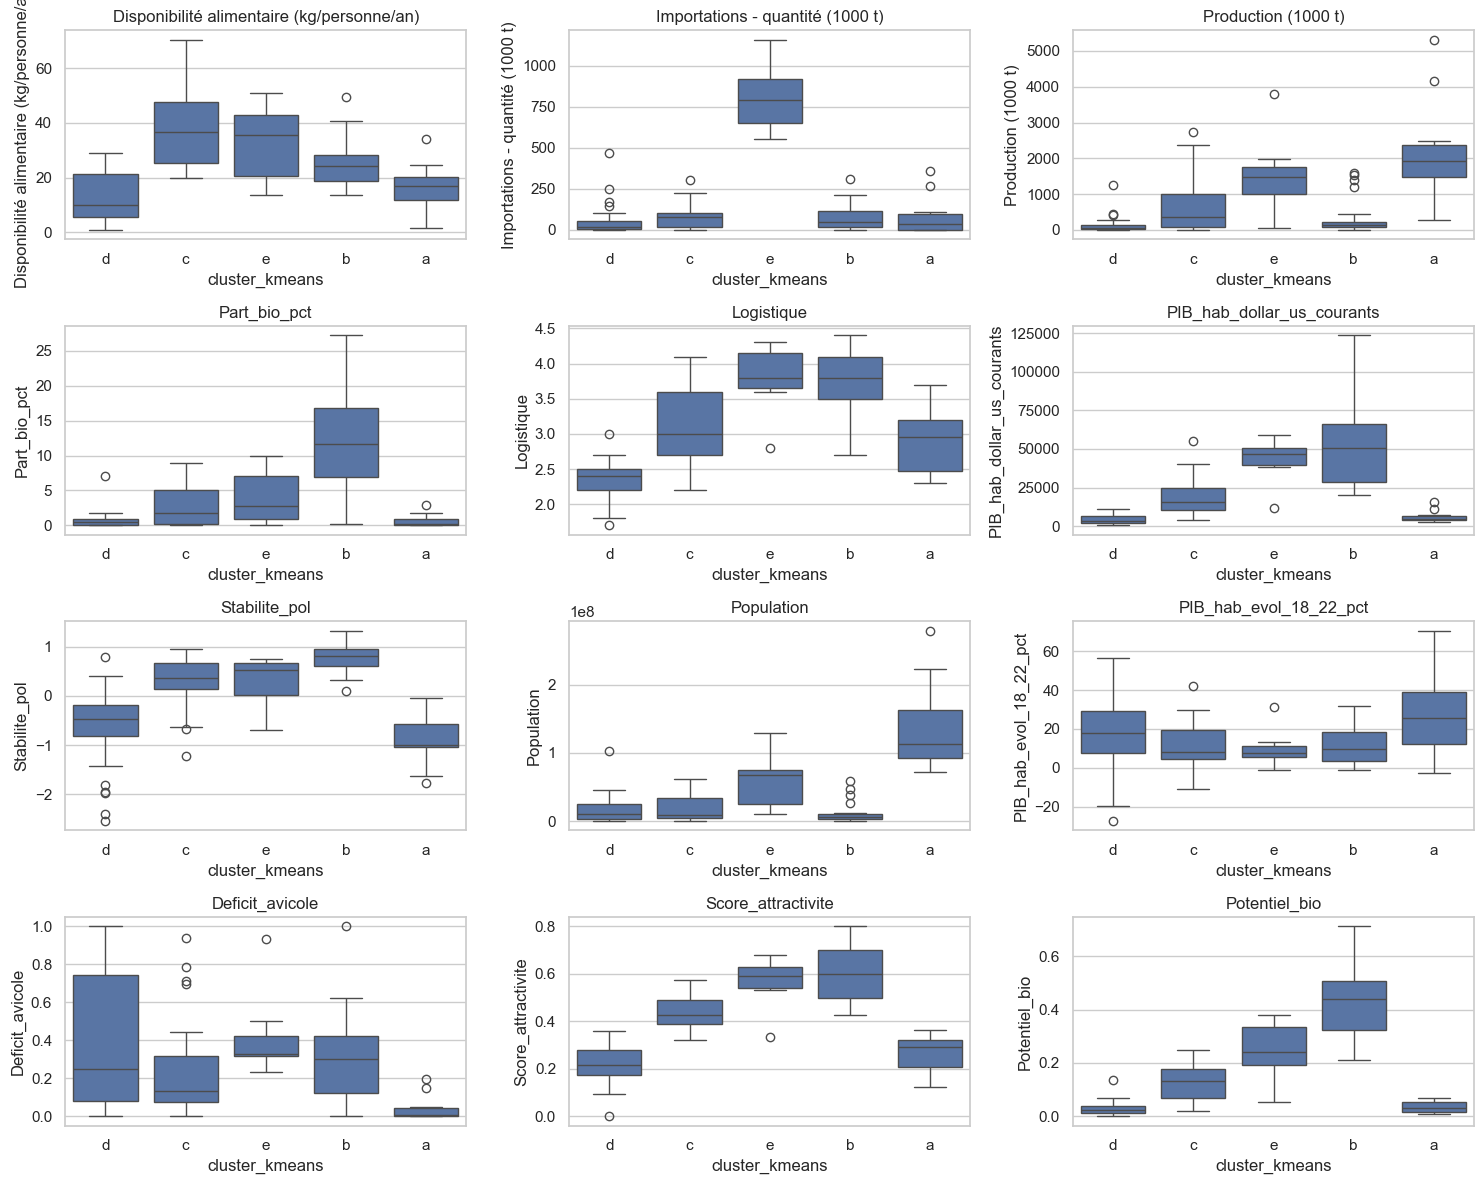

In [77]:
# Création des boxplots par cluster kmeans pour toutes les variables

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
sns.set(style="whitegrid")

for idx, var in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_kmeans_flat, x='cluster_kmeans', y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.savefig("data-output/N2-boxplot_cluster_kmeans.png", dpi=300, bbox_inches='tight')
plt.show()

In [78]:
# Création du dataframe des moyennes
df_kmeans_moyenne = df_kmeans_flat.drop(columns="Pays").groupby('cluster_kmeans').mean().round(2)
df_kmeans_moyenne

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
cluster_kmeans,,,,,,,,,,,,
a,16.01,87.50,2156.40,0.71,2.92,6042.36,-0.91,1.388106e+08,26.05,0.04,0.27,0.04
b,25.06,80.70,355.78,11.86,3.73,52814.70,0.78,1.209087e+07,11.72,0.31,0.60,0.43
c,38.14,79.96,711.32,2.70,3.07,19430.76,0.26,1.771350e+07,11.49,0.25,0.44,0.13
d,13.05,55.58,131.32,0.78,2.34,4265.38,-0.67,1.791145e+07,16.51,0.41,0.22,0.03
e,32.44,807.43,1547.14,4.10,3.79,42621.61,0.28,5.821865e+07,10.23,0.43,0.56,0.25


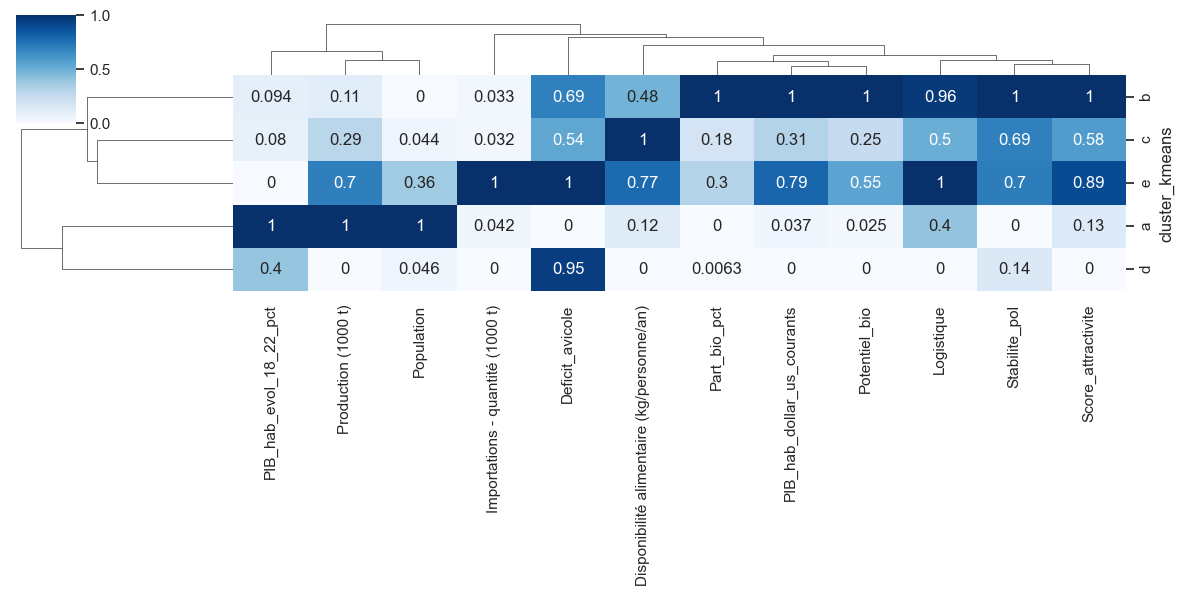

In [79]:
# Clustermap
sns.clustermap(df_kmeans_moyenne, figsize=(12, 6), annot=True,
               standard_scale=1, cmap='Blues')
plt.savefig("data-output/N2-clustermap_kmeans.png")
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.6 Stockage clusters intéressants</h4>
</div>

In [80]:
# df_kmeans cluster e, trié par ordre décroissant score_attractivite, garder uniquement pays et score attractivité
df_kmeans_cluster_e = df_kmeans_flat[df_kmeans_flat["cluster_kmeans"]=="e"][["Pays", "Score_attractivite","cluster_kmeans"]].sort_values(by="Score_attractivite", ascending=False)
df_kmeans_cluster_e

,Pays,Score_attractivite,cluster_kmeans
94,Émirats arabes unis,0.6787,e
68,Pays-Bas (Royaume des),0.6371,e
4,Allemagne,0.6223,e
74,Royaume-Uni de Grande-Bretagne et d’Irlande du...,0.5918,e
31,France,0.5502,e
5,Arabie saoudite,0.5341,e
59,Mexique,0.3344,e


In [81]:
# df_kmeans cluster b, trié par ordre décroissant score_attractivite, garder uniquement pays et score attractivité
df_kmeans_cluster_b = df_kmeans_flat[df_kmeans_flat["cluster_kmeans"]=="b"][["Pays", "Score_attractivite","cluster_kmeans"]].sort_values(by="Score_attractivite", ascending=False)
df_kmeans_cluster_b

,Pays,Score_attractivite,cluster_kmeans
54,Luxembourg,0.8000,b
83,Suisse,0.7931,b
62,Norvège,0.7772,b
44,Irlande,0.7488,b
8,Australie,0.7393,b
45,Islande,0.7026,b
19,Canada,0.7006,b
25,Danemark,0.6707,b
30,Finlande,0.6448,b
84,Suède,0.6435,b


In [82]:
# df_kmeans cluster c, trié par ordre décroissant score_attractivite, garder uniquement pays et score attractivité
df_kmeans_cluster_c = df_kmeans_flat[df_kmeans_flat["cluster_kmeans"]=="c"][["Pays", "Score_attractivite","cluster_kmeans"]].sort_values(by="Score_attractivite", ascending=False)
df_kmeans_cluster_c

,Pays,Score_attractivite,cluster_kmeans
46,Israël,0.5752,c
75,République de Corée,0.5681,c
58,Malte,0.5620,c
51,Koweït,0.5574,c
10,Bahamas,0.5333,c
71,Portugal,0.5296,c
57,Malaisie,0.4894,c
70,Pologne,0.4865,c
65,Panama,0.4805,c
21,Chypre,0.4497,c


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.3 (a) Dataframe des pays intéressants</h3>
</div>

In [83]:
# Rappel des clusters intéressants :
df_cah_cluster3
df_kmeans_cluster_b
df_kmeans_cluster_c
df_kmeans_cluster_e

,Pays,Score_attractivite,cluster_kmeans
94,Émirats arabes unis,0.6787,e
68,Pays-Bas (Royaume des),0.6371,e
4,Allemagne,0.6223,e
74,Royaume-Uni de Grande-Bretagne et d’Irlande du...,0.5918,e
31,France,0.5502,e
5,Arabie saoudite,0.5341,e
59,Mexique,0.3344,e


In [84]:
df_pays_retenus = pd.concat([df_cah_cluster3,df_kmeans_cluster_b, df_kmeans_cluster_c, df_kmeans_cluster_e])[["Pays","Score_attractivite"]].drop_duplicates().sort_values(by="Score_attractivite", ascending=False).reset_index(drop=True)
df_pays_retenus.head(5)

,Pays,Score_attractivite
0,Luxembourg,0.8000
1,Suisse,0.7931
2,Norvège,0.7772
3,Irlande,0.7488
4,Australie,0.7393


In [85]:
df_pays_retenus_identifiant = pd.merge(df_pays_retenus[["Pays"]], df_brut.reset_index(), on = "Pays", how="left")
df_pays_retenus_identifiant.head(5)

,Pays,Year,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Region,M49 Code,ISO-alpha3 Code,Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio
0,Luxembourg,2022,19.70,14.0,0.0,Europe,442,LUX,6.23,3.6,123719.658916,1.064390,653103.0,5.8,1.0000,0.8000,0.6146
1,Suisse,2022,17.90,49.0,112.0,Europe,756,CHE,12.38,4.4,94394.510680,1.159745,8777088.0,10.8,0.3043,0.7931,0.6090
2,Norvège,2022,21.36,4.0,115.0,Europe,578,NOR,4.67,3.9,109269.520580,0.861239,5457127.0,32.0,0.0336,0.7772,0.5274
3,Irlande,2022,29.99,110.0,160.0,Europe,372,IRL,2.27,3.5,105190.685953,0.884667,5212836.0,30.2,0.4074,0.7488,0.4667
4,Australie,2022,49.51,4.0,1396.0,Océanie,36,AUS,9.82,4.1,65169.519112,0.983716,26018721.0,13.5,0.0029,0.7393,0.4434


In [86]:
df_pays_retenus_identifiant = df_pays_retenus_identifiant[["Pays", "Region", "ISO-alpha3 Code", "Score_attractivite"]]
df_pays_retenus_identifiant.head(5)

,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Luxembourg,Europe,LUX,0.8000
1,Suisse,Europe,CHE,0.7931
2,Norvège,Europe,NOR,0.7772
3,Irlande,Europe,IRL,0.7488
4,Australie,Océanie,AUS,0.7393


In [87]:
df_pays_retenus_identifiant.to_csv("data-output/df_pays_retenus_identifiant.csv", index=False)

In [88]:
# Créer un tableau des pays par région (boucle for) avec le top 10 des pays les plus attractifs ("Score_attractivite") par région
pays_par_region_1 = df_pays_retenus_identifiant.groupby('Region')
for region in pays_par_region_1.groups.keys() :
    print(f"Région : {region}")
    top_10 = pays_par_region_1.get_group(region).sort_values(by="Score_attractivite", ascending=False ).reset_index(drop=True)
    display(top_10)
    print("\n")

Région : Afrique


,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Afrique du Sud,Afrique,ZAF,0.3887




Région : Amériques


,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Canada,Amériques,CAN,0.7006
1,Bahamas,Amériques,BHS,0.5333
2,Panama,Amériques,PAN,0.4805
3,Uruguay,Amériques,URY,0.4382
4,Costa Rica,Amériques,CRI,0.4264
5,Argentine,Amériques,ARG,0.4011
6,Chili,Amériques,CHL,0.3992
7,Jamaïque,Amériques,JAM,0.3885
8,République dominicaine,Amériques,DOM,0.3787
9,Mexique,Amériques,MEX,0.3344




Région : Asie


,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Émirats arabes unis,Asie,ARE,0.6787
1,Israël,Asie,ISR,0.5752
2,République de Corée,Asie,KOR,0.5681
3,Koweït,Asie,KWT,0.5574
4,Arabie saoudite,Asie,SAU,0.5341
5,Malaisie,Asie,MYS,0.4894
6,Chypre,Asie,CYP,0.4497
7,Oman,Asie,OMN,0.4435




Région : Europe


,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Luxembourg,Europe,LUX,0.8000
1,Suisse,Europe,CHE,0.7931
2,Norvège,Europe,NOR,0.7772
3,Irlande,Europe,IRL,0.7488
4,Islande,Europe,ISL,0.7026
5,Danemark,Europe,DNK,0.6707
6,Finlande,Europe,FIN,0.6448
7,Suède,Europe,SWE,0.6435
8,Pays-Bas (Royaume des),Europe,NLD,0.6371
9,Allemagne,Europe,DEU,0.6223




Région : Océanie


,Pays,Region,ISO-alpha3 Code,Score_attractivite
0,Australie,Océanie,AUS,0.7393
1,Nouvelle-Zélande,Océanie,NZL,0.6374
2,Fidji,Océanie,FJI,0.3827


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.3 (b) Carte des pays intéressants</h3>
</div>

In [89]:
import folium
from folium import plugins
import geopandas as gpd

# Charger le shapefile depuis le dossier geodata
world = gpd.read_file("geodata/ne_110m_admin_0_countries.shp")
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [90]:
# Fusionner sur le code ISO
world_data = world.merge(
    df_pays_retenus_identifiant,
    left_on='ISO_A3',
    right_on='ISO-alpha3 Code',
    how='left'
)

print(f"Pays fusionnés: {world_data[world_data['Region'].notna()].shape[0]}")

Pays fusionnés: 52


In [96]:
# Calculer le nombre de pays par région
pays_par_region = df_pays_retenus_identifiant.groupby('Region').size().reset_index(name='Nombre_Pays')
print(pays_par_region)

# Coordonnées approximatives du centre de chaque région
centres_regions = {
    'Europe': [54, 10],
    'Asie': [34, 100],
    'Afrique': [0, 20],
    'Amériques': [10, -70],
    'Océanie': [-25, 135]
}

# Créer la carte
map_regions = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles='OpenStreetMap'
)

# Ajouter la politique de référent
map_regions.get_root().html.add_child(folium.Element(
    '<meta name="referrer" content="origin-when-cross-origin">'
))

# Ajouter des bulles pour chaque région
for _, row in pays_par_region.iterrows():
    region = row['Region']
    nombre = row['Nombre_Pays']

    if region in centres_regions:
        lat, lon = centres_regions[region]

        # Créer une icône avec le nombre centré
        icon_html = f'''
            <div style="
                width: 40px;
                height: 40px;
                background-color: #3498db;
                border: 2px solid #2c3e50;
                border-radius: 50%;
                display: flex;
                align-items: center;
                justify-content: center;
                font-size: 16px;
                font-weight: bold;
                color: white;
            ">
                {nombre}
            </div>
        '''

        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(html=icon_html),
            popup=f"{region}<br>{nombre} pays",
            tooltip=region
        ).add_to(map_regions)

map_regions

      Region  Nombre_Pays
0    Afrique            1
1  Amériques           13
2       Asie            8
3     Europe           30
4    Océanie            3


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">4.4 Analyse comparative entre les deux méthodes</h3>
</div>

On va maintenant comparer nos résultats de clustering CAH et K-means.
<br>Pour cela, il existe plusieurs indices de qualité interne qui permette d'évaluer la qualité intrinsèque de chaque partition.

<br> --> Silhouette
<br>
<br>Mesure si les points sont bien regroupés dans leur cluster et éloignés des autres
<br>Score entre -1 et 1 : plus proche de 1, mieux c'est
<br>Permet de comparer les deux méthodes directement
<br>Utile aussi pour ajuster le nombre de clusters
<br>
<br>--> Indice de Davies-Bouldin
<br>
<br>Ratio entre similitude intra-cluster et inter-cluster
<br>Plus bas est mieux (0 = idéal)
<br>Sensible au nombre de clusters
<br>
<br>--> Indice de Calinski-Harabasz
<br>
<br>Ratio de variance inter/intra-cluster
<br>Plus élevé est mieux
<br>Robuste et facile à interpréter 


In [92]:

# Indices de qualité
sil_cah = silhouette_score(X_scaled, clusters_cah)
sil_kmeans = silhouette_score(X_scaled, kmeans.labels_)

db_cah = davies_bouldin_score(X_scaled, clusters_cah)
db_kmeans = davies_bouldin_score(X_scaled, kmeans.labels_)

ch_cah = calinski_harabasz_score(X_scaled, clusters_cah)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans.labels_)

print("--- Indices de qualité ---")
print(f"Silhouette | CAH: {sil_cah:.3f}, K-means: {sil_kmeans:.3f}")
print(f"Davies-Bouldin | CAH: {db_cah:.3f}, K-means: {db_kmeans:.3f}")
print(f"Calinski-Harabasz | CAH: {ch_cah:.3f}, K-means: {ch_kmeans:.3f}")

# Accord entre les deux méthodes
ari = adjusted_rand_score(clusters_cah, kmeans.labels_)
ami = adjusted_mutual_info_score(clusters_cah, kmeans.labels_)
print("\n--- Accord entre les deux méthodes ---")
print(f"ARI: {ari:.3f} (accord entre partitions)")
print(f"AMI: {ami:.3f}")

--- Indices de qualité ---
Silhouette | CAH: 0.216, K-means: 0.214
Davies-Bouldin | CAH: 1.389, K-means: 1.357
Calinski-Harabasz | CAH: 24.421, K-means: 26.288

--- Accord entre les deux méthodes ---
ARI: 0.649 (accord entre partitions)
AMI: 0.698


Les deux méthodes produisent des partitions similaires. 

On peut retenir l'une ou l'autre méthode.

Pour la projection des individus

<div style="border: 1px solid white; background:rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px; color:white ">ETAPE 5 : SUITE ACP - PROJECTION DES INDIVIDUS</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.1 Préparation du dataset</h3>
</div>

In [93]:
#Pour rappel
display(df_cah_pays_index.head())
display(df_kmeans_pays_index.head())

,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_cah
Pays,,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,4
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,5
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,4
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,4
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,2


,Disponibilité alimentaire (kg/personne/an),Importations - quantité (1000 t),Production (1000 t),Part_bio_pct,Logistique,PIB_hab_dollar_us_courants,Stabilite_pol,Population,PIB_hab_evol_18_22_pct,Deficit_avicole,Score_attractivite,Potentiel_bio,cluster_kmeans
Pays,,,,,,,,,,,,,
Afghanistan,0.87,7.0,29.0,0.00,1.7,357.261153,-2.544956,40578842.0,-27.3,0.1944,0.0000,0.0000,d
Afrique du Sud,35.47,304.0,1958.0,0.05,3.6,6534.248678,-0.681386,62378410.0,-5.5,0.1344,0.3887,0.0260,c
Albanie,22.68,47.0,18.0,0.06,2.7,7756.961887,0.106261,2451636.0,31.5,0.7231,0.3321,0.0311,d
Algérie,9.71,0.0,443.0,0.00,2.1,4960.303343,-0.650652,45477389.0,8.4,0.0000,0.1917,0.0187,d
Allemagne,16.63,789.0,1508.0,9.67,4.3,50506.517964,0.628492,83177813.0,3.3,0.3435,0.6223,0.3812,e


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.2 Utilisation des clusters de la méthode CAH</h3>
</div>

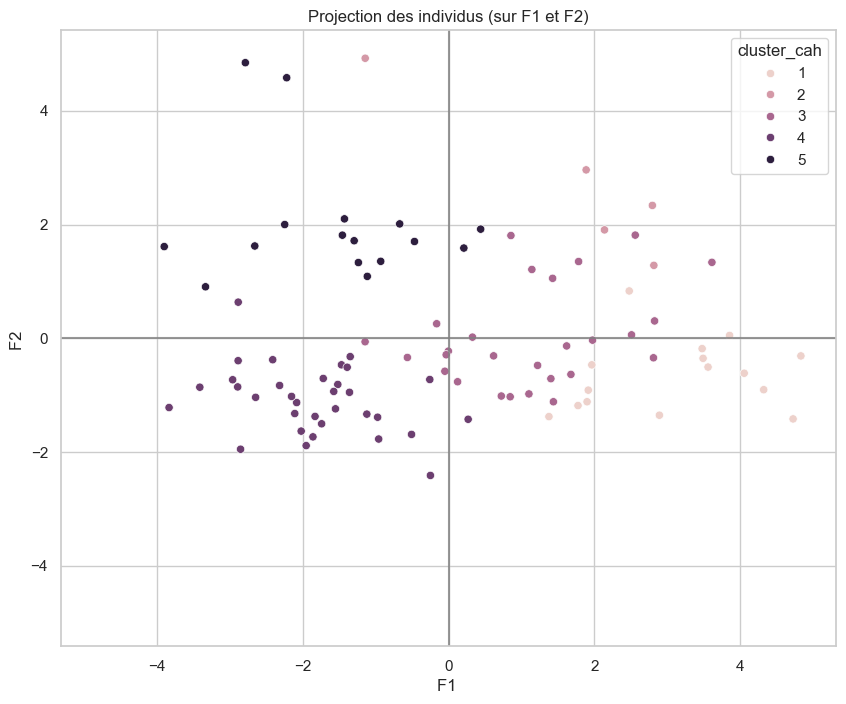

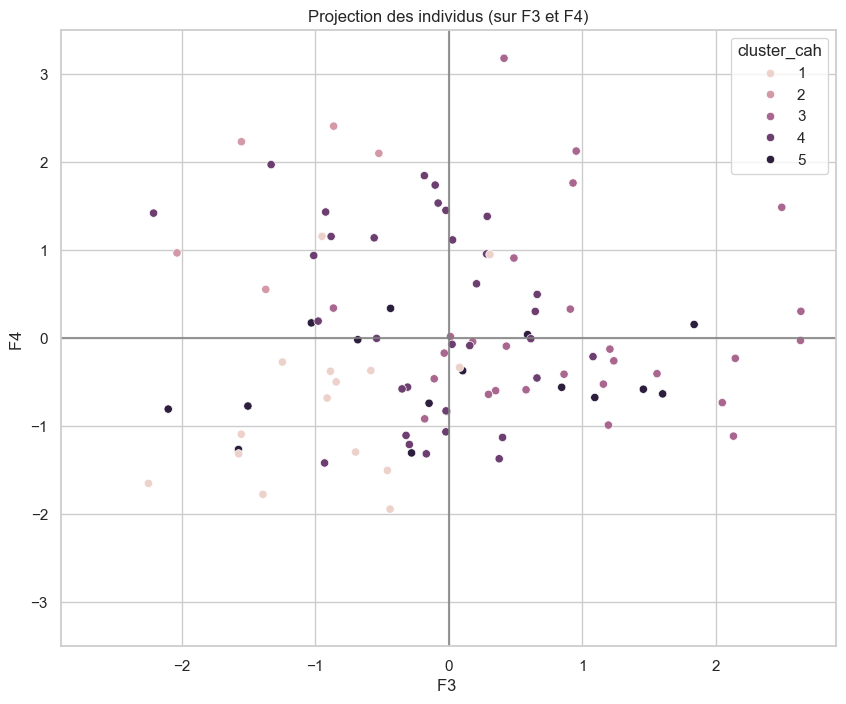

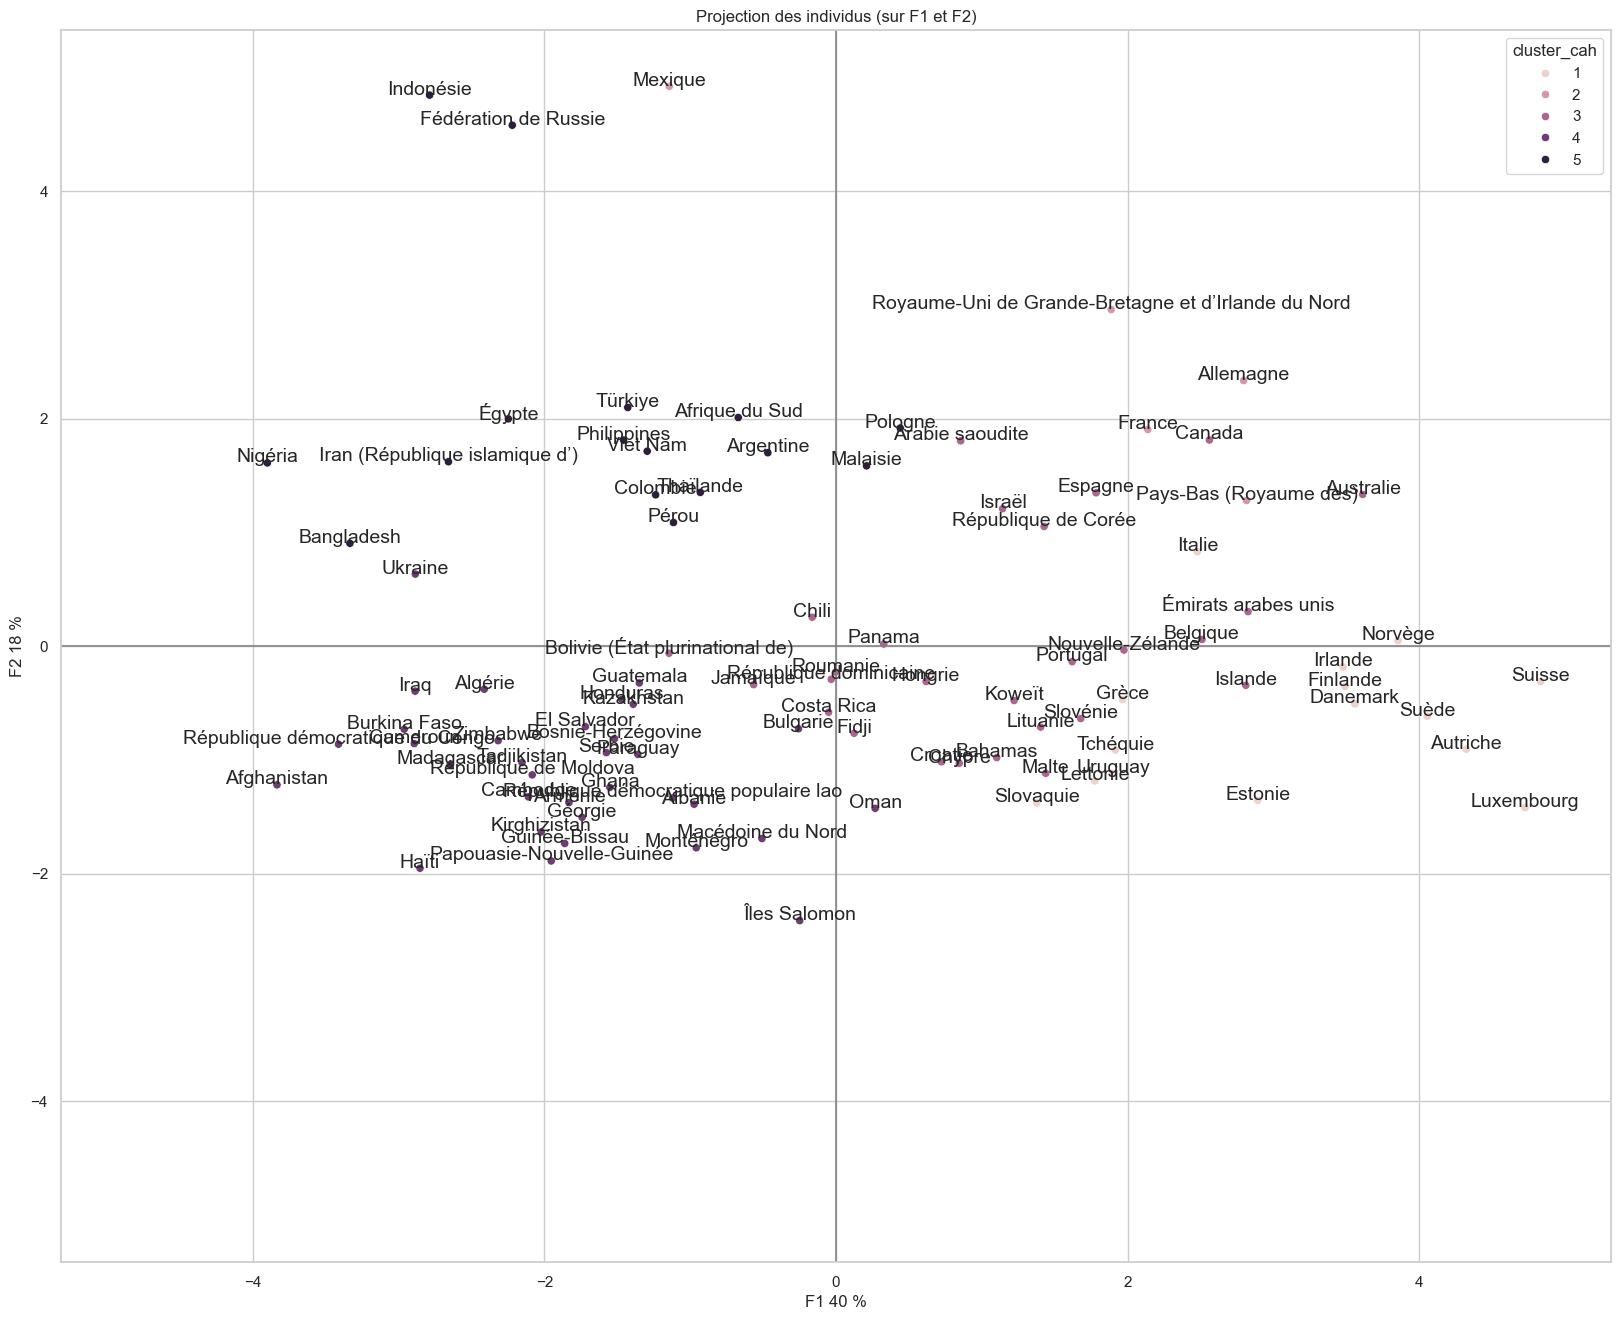

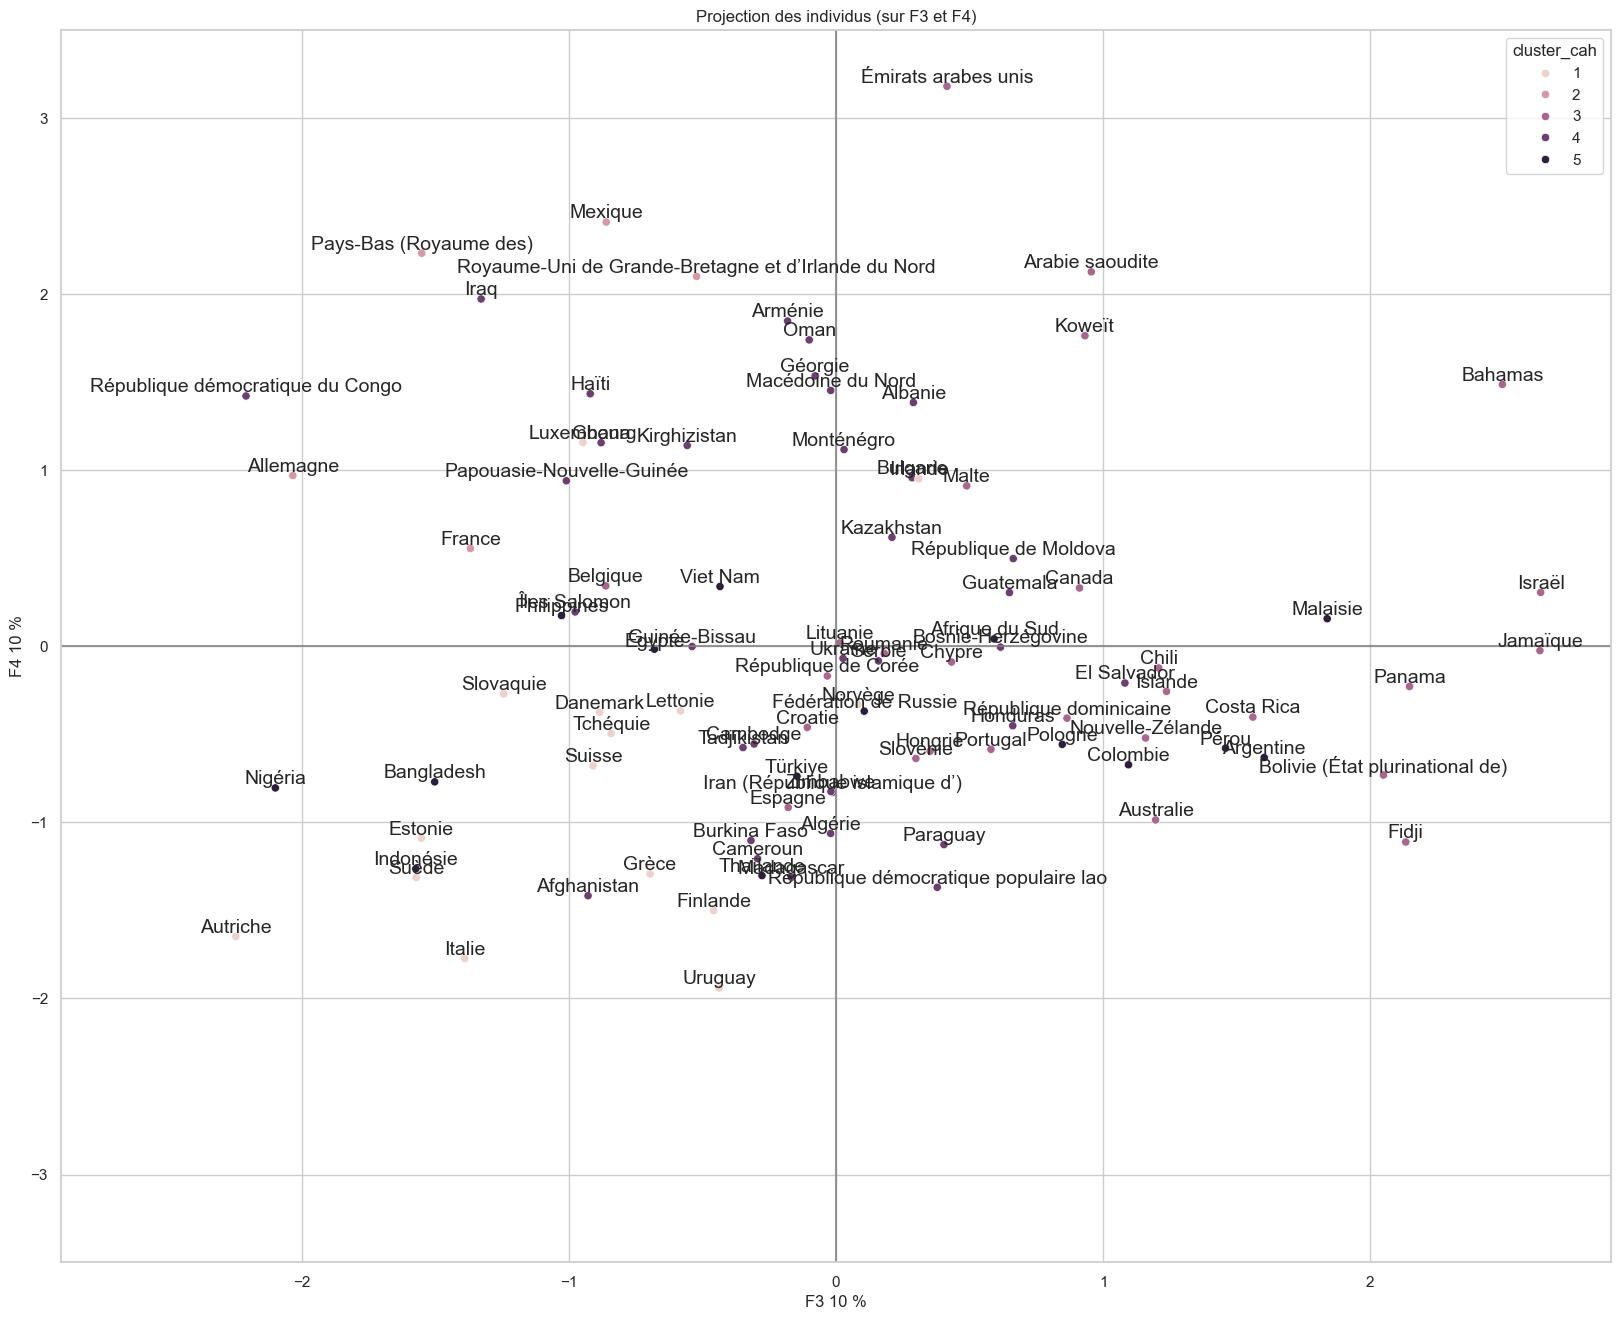

In [94]:
# Version simple avec F1 et F2, les couleurs correspondent au PIB par habitant
display_factorial_planes(X_proj, [0,1], clusters=df_cah_pays_index["cluster_cah"])
display_factorial_planes(X_proj, [2,3], clusters=df_cah_pays_index["cluster_cah"])
display_factorial_planes(X_proj, [0,1], pca, labels=names, figsize=(20,16), clusters=df_cah_pays_index["cluster_cah"], marker="o")
display_factorial_planes(X_proj, [2,3], pca, labels=names, figsize=(20,16), clusters=df_cah_pays_index["cluster_cah"], marker="o")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">5.3 Utilisation des clusters de la méthode Kmeans</h3>
</div>

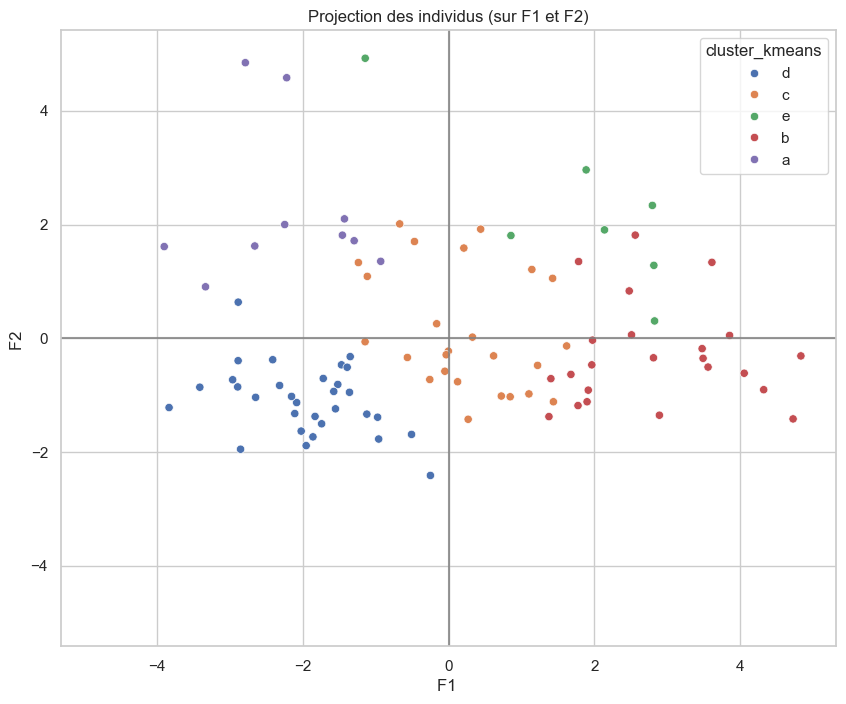

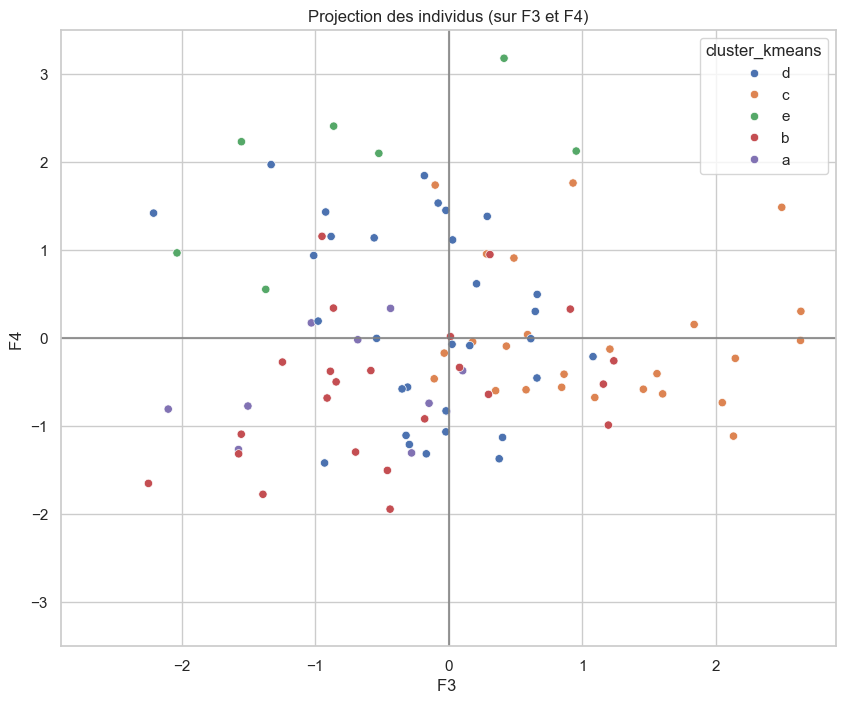

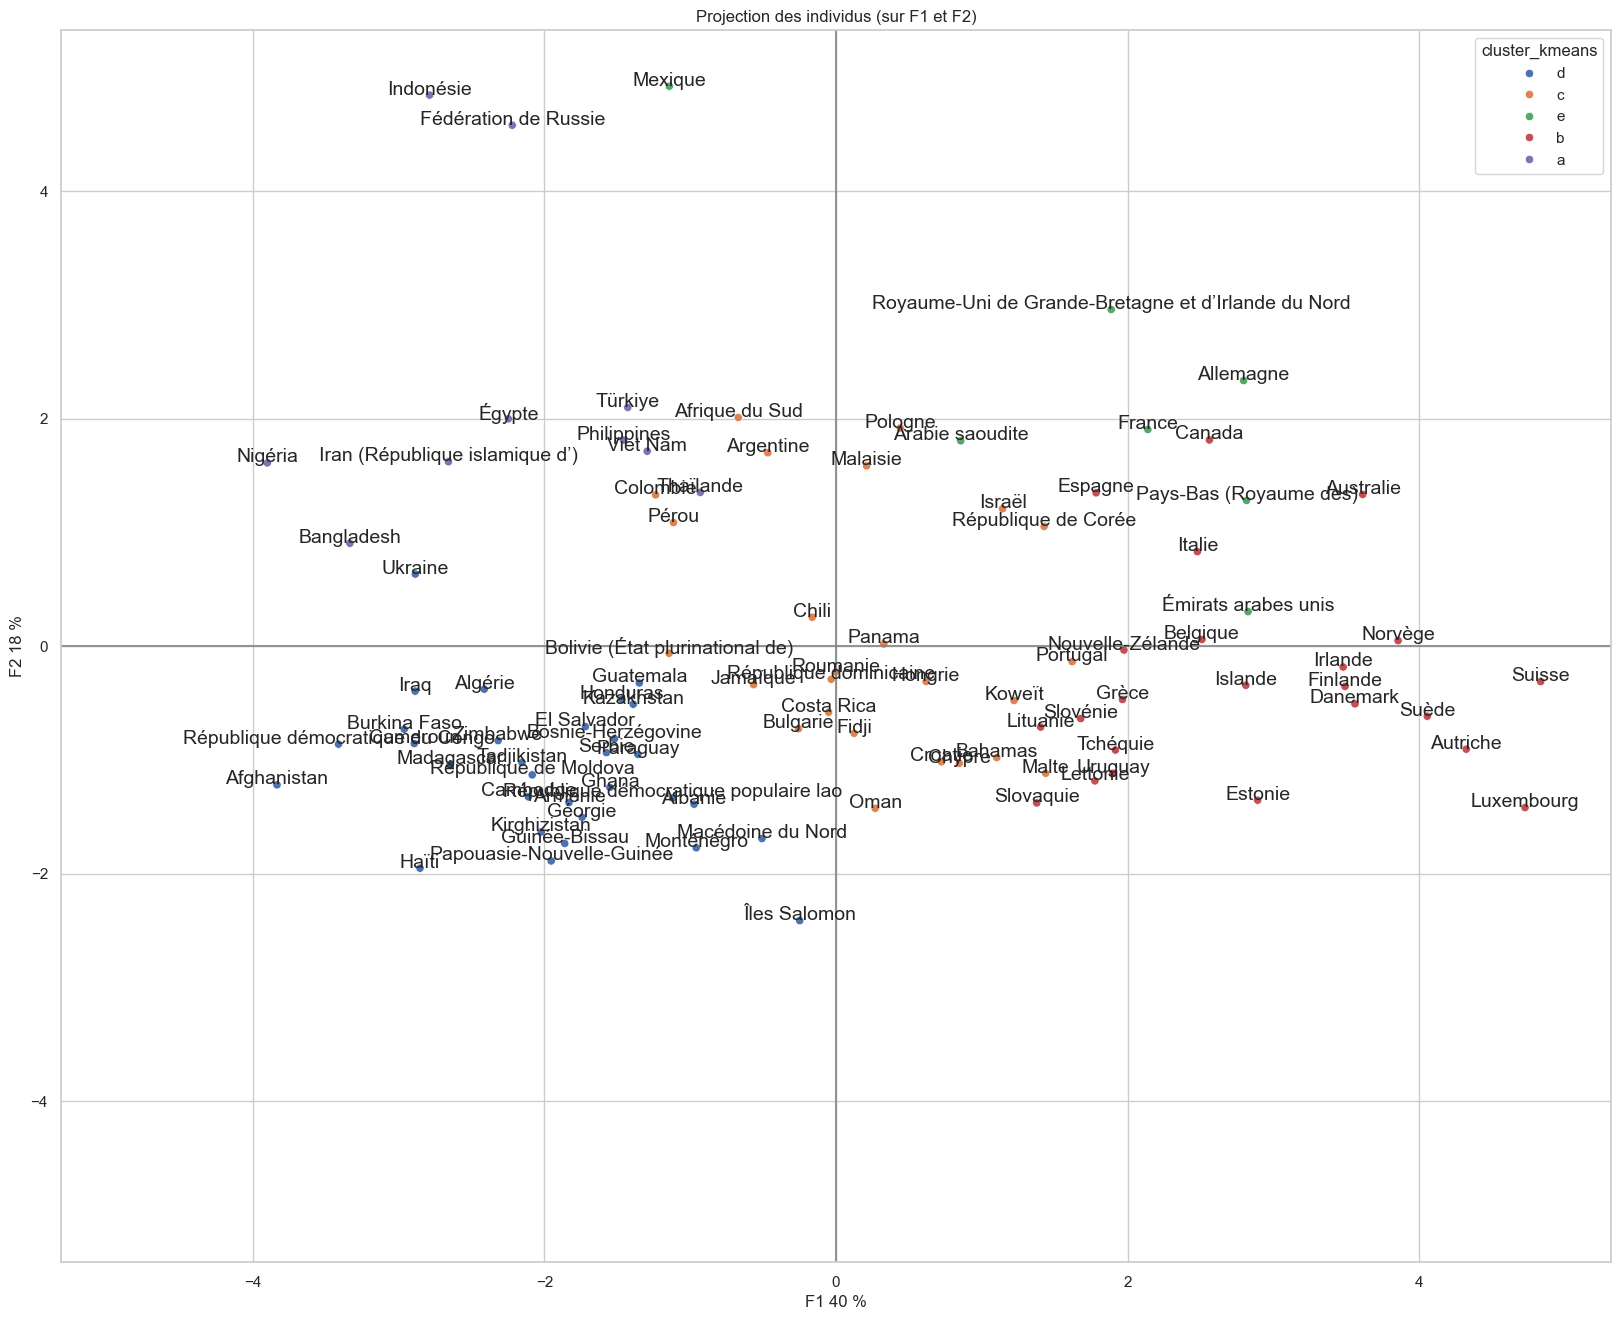

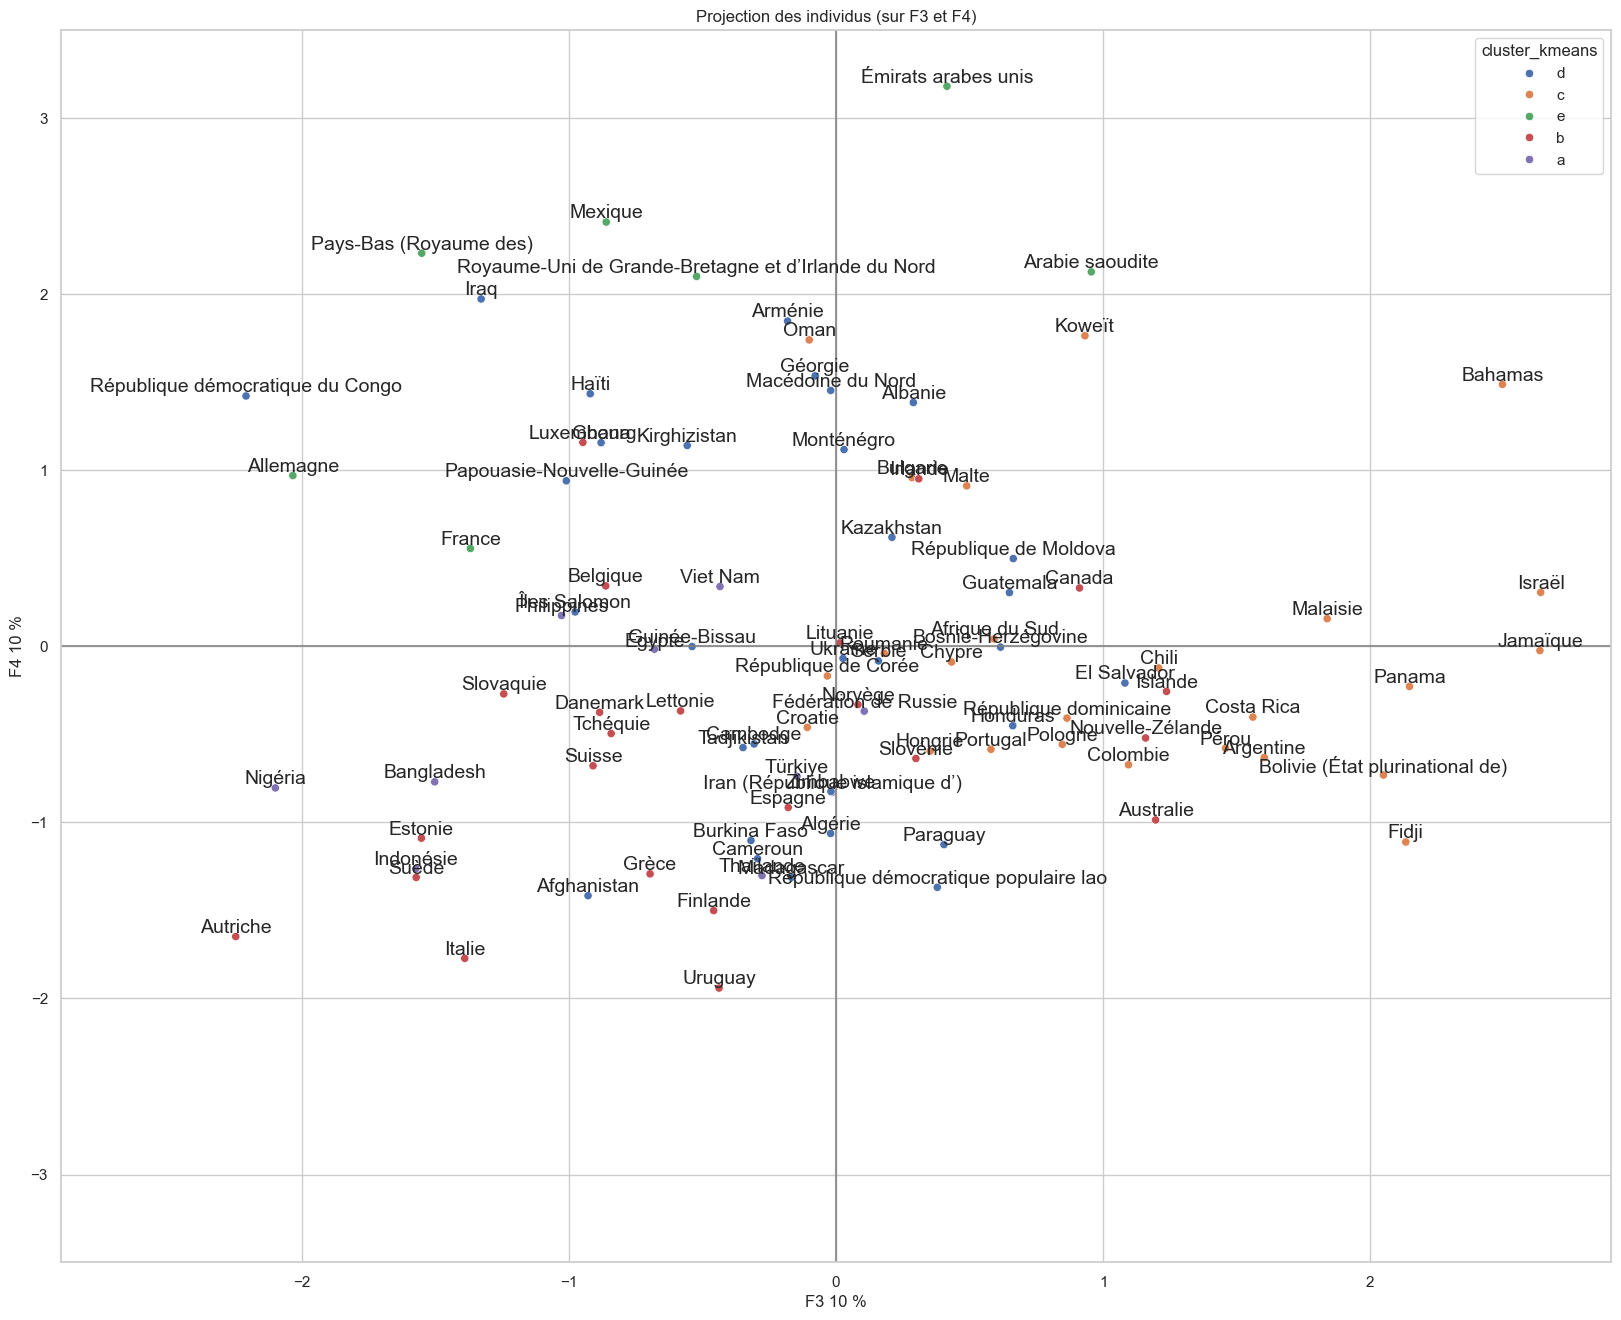

In [95]:
# Version simple avec F1 et F2, les couleurs correspondent au PIB par habitant
display_factorial_planes(X_proj, [0,1], clusters=df_kmeans_pays_index["cluster_kmeans"])
display_factorial_planes(X_proj, [2,3], clusters=df_kmeans_pays_index["cluster_kmeans"])
display_factorial_planes(X_proj, [0,1], pca, labels=names, figsize=(20,16), clusters=df_kmeans_pays_index["cluster_kmeans"], marker="o")
display_factorial_planes(X_proj, [2,3], pca, labels=names, figsize=(20,16), clusters=df_kmeans_pays_index["cluster_kmeans"], marker="o")